# **Tutorial 4** $\cdot$ Uncertainty Quantification

> **Abstract.** This tutorial introduces *uncertainty quantification (UQ)* for molecular property prediction. Unlike the attribution and counterfactual methods of the previous tutorials, UQ methods do not explain *why* a model made a given prediction &mdash; instead, they quantify *how confident* the model is in that prediction. We demonstrate *deep ensembles with mean-variance estimation (MVE)*: an ensemble of independently trained graph neural networks, each of which predicts not only a target value but also its own per-input variance. Their outputs are combined through a moment-matched mixture-of-Gaussians aggregation that *separates* the uncertainty into an *aleatoric* component (irreducible noise in the data) and an *epistemic* component (disagreement between models) &mdash; which, as we will see, are best used for different jobs: the recalibrated total uncertainty as a calibrated error bar, and the epistemic spread as a distribution-shift detector. Using the AqSolDB water solubility dataset as a case study, we train the ensemble and then evaluate the resulting uncertainty estimates in two complementary ways: their *calibration* on in-distribution data, where uncertainty should track the prediction error, and their *sensitivity to distribution shift*, where uncertainty should rise as the test molecules become progressively less like the training data. For the latter we construct three out-of-distribution (OOD) tiers that probe different kinds of distribution shift &mdash; ranging from larger drug-like molecules, through familiar molecules carrying an unseen chemical element, all the way to large polycyclic aromatic hydrocarbons (PAHs) far outside the chemistry the model has ever seen.


**💾 Datasets.** The primary dataset is the [AqSolDB](https://www.kaggle.com/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset) dataset introduced by [Sorkun et al.](https://www.nature.com/articles/s41597-019-0151-1) &mdash; the same regression benchmark used in Tutorials 1 and 3 &mdash; on which the ensemble is trained. To probe out-of-distribution behavior we additionally use three small auxiliary sets shipped with this package, each loaded through its own helper function: the heaviest AqSolDB molecules (`load_dataset_aqsoldb_heaviest`), recognizable AqSolDB molecules with every halogen replaced by the unseen element astatine (`load_dataset_astatine_substituted`), and ~50 polycyclic aromatic hydrocarbons (PAHs) (`load_dataset_pahs`).

**📦 Packages.** Packages used in this notebook include:
- [RDKit](https://www.rdkit.org/docs/index.html) Cheminformatics framework for processing of SMILES strings.
- [Pandas](https://pandas.pydata.org/docs/index.html) for data representation and processing.
- [Pytorch](https://docs.pytorch.org/docs/stable/index.html) and [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) for the training of the individual ensemble members.
- [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) framework for the construction of the graph neural network ensemble.
- [NetworkX](https://networkx.org/) for the intermediate molecular graph representation.

In [1]:
import os
import json
import copy
import random
import warnings

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import rdkit.Chem as Chem
import lightning.pytorch as pl
import torch.nn as nn
import torch.nn.functional as F
from rich.pretty import pprint
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool
from torch.nn.utils.parametrizations import spectral_norm

warnings.filterwarnings('ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from xai_chem_review import load_dataset_aqsoldb
from xai_chem_review import load_dataset_pahs
from xai_chem_review import load_dataset_aqsoldb_heaviest
from xai_chem_review import load_dataset_astatine_substituted

# Fix the random seeds for reproducibility of the train-test split and the
# ensemble subsampling. The remaining randomness in ensemble member training
# (weight initialisation, batch shuffling) is what gives the ensemble its diversity.
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

The `load_dataset_aqsoldb` function loads and returns the AqSolDB dataset into a pandas `DataFrame` object. Each molecule is represented as a [SMILES](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System) string with a continuous water solubility value (logS).

In [2]:
data_frame: pd.DataFrame = load_dataset_aqsoldb()
print(f'Loaded dataset with {data_frame.shape[0]} rows')
data_frame.head()

Loaded dataset with 11024 rows


,index,ID,smiles,InChIKey,solubility,split
0,0,A-10,Cc1cccc(C=C)c1,JZHGRUMIRATHIU-UHFFFAOYSA-N,-3.123150,1
1,1,A-100,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,ODJUOZPKKHIEOZ-UHFFFAOYSA-N,-4.952869,1
2,2,A-1000,O=C1CCCCCCCCCOCCCCCO1,MKEIDVFLAWJKMY-UHFFFAOYSA-N,-3.883849,1
3,3,A-1002,CCCCCCCCCCC(C)CCCCCCCC,FFVPRSKCTDQLBP-UHFFFAOYSA-N,-6.451105,1
4,4,A-1003,NC(=O)N=NC(N)=O,XOZUGNYVDXMRKW-UHFFFAOYSA-N,-3.546243,1


In [3]:
data_frame['mol'] = data_frame['smiles'].apply(Chem.MolFromSmiles)
data_frame = data_frame.dropna(subset=['mol']).reset_index(drop=True)
print(f'After mol conversion {data_frame.shape[0]} rows remaining')

After mol conversion 11022 rows remaining


## **4.1** $\cdot$ 💡 Uncertainty Quantification

The previous tutorials have introduced explanation methods that aim to make a model's predictions *interpretable* &mdash; either by attributing importance to features and substructures, or by suggesting structural modifications that would change the prediction. All of these methods share an implicit assumption: that the prediction itself is *trustworthy enough to be worth explaining*. In real-world deployment, however, machine-learning models frequently encounter inputs that look nothing like their training data &mdash; novel chemical scaffolds, or even entirely new classes of compounds. On such inputs models often produce confidently wrong predictions, and any explanation generated for such a prediction would explain a hallucination rather than a meaningful chemical insight.

*Uncertainty quantification (UQ)* methods address this gap. Rather than explaining a prediction, they attach a second number to it: an estimate of *how reliable* that prediction is likely to be. A useful uncertainty estimate should be *small* on inputs the model is well-equipped to handle &mdash; where predictions are close to the ground truth on average &mdash; and *large* on inputs where the model is operating outside its competence. In practice this allows a downstream user to triage predictions: trust the low-uncertainty estimates, double-check the high-uncertainty ones, and reject those above some threshold entirely.

**Relevance to Molecular Property Prediction.** Chemical space is vast &mdash; far larger than any training set can hope to cover. A model trained on a curated dataset of small drug-like molecules has, in a meaningful sense, only seen a tiny corner of this space. When such a model is asked to predict properties of larger molecules, of compounds containing unusual atoms, or of polymers and biomolecules, it will still produce a number &mdash; but that number may be essentially arbitrary. Well-calibrated uncertainty estimates allow practitioners in drug discovery and materials science to recognize such situations *before* acting on the predictions.

**Aleatoric vs. Epistemic Uncertainty.** Conceptually, prediction uncertainty has two distinct sources. *Aleatoric* uncertainty arises from inherent noise in the data &mdash; for example the experimental measurement error in the recorded solubility values. This source of uncertainty cannot be reduced by collecting more training data of the same kind. *Epistemic* uncertainty, in contrast, arises from the limited knowledge of the model &mdash; regions of input space where the training data is sparse or absent &mdash; and can in principle be reduced by training on more diverse data. The mean-variance ensemble introduced in this tutorial captures *both*: the per-member variance heads estimate the aleatoric part, while the disagreement between members estimates the epistemic part. As we will see, separating the two is what lets us use the same model both as a calibrated error bar and as a detector of distribution shift. Deep ensembles are far from the only route to UQ &mdash; Monte-Carlo dropout ([Gal & Ghahramani, 2016](https://arxiv.org/abs/1506.02142)) and single-network mean-variance estimation ([Nix & Weigend, 1994](https://doi.org/10.1109/ICNN.1994.374138)) are two common alternatives, and [Hirschfeld et al. (2020)](https://doi.org/10.1021/acs.jcim.0c00502) survey several in the molecular-property setting &mdash; but ensembles remain among the simplest and most reliable, which is why we use them here.

## **4.2** $\cdot$ 📚 *Deep Ensembles with Mean-Variance Estimation*

The conceptually simplest and empirically one of the most effective approaches to uncertainty quantification for neural networks was popularized by [Lakshminarayanan *et al.*](https://arxiv.org/abs/1612.01474) under the name *deep ensembles*. The original idea is straightforward: train an ensemble of several networks that solve the same task and use the *disagreement* between their predictions as an uncertainty estimate. We extend this approach in two ways:

1. **Mean-Variance Estimation (MVE).** Each ensemble member predicts not just a scalar mean $\mu_{\theta_m}(\mathbf{x})$ but also a per-input variance $\sigma^2_{\theta_m}(\mathbf{x})$. The variance head is a small MLP on top of the same graph embedding the mean head uses, trained jointly with the mean head against a Gaussian negative log-likelihood (NLL) loss. (Intuitively, the NLL measures how *surprised* a predicted Gaussian is by the true label: it trades off a term that punishes an over-large $\sigma$ against one that punishes errors much larger than $\sigma$, so the model is pushed to report a $\sigma$ that matches its typical error.) This gives each individual member the ability to express its own *aleatoric* uncertainty &mdash; the irreducible noise it expects in the label &mdash; rather than relying solely on inter-member disagreement.

2. **Moment-matched aggregation.** When the $M$ ensemble members each output a Gaussian, the ensemble as a whole defines a *mixture of Gaussians*, which is not itself Gaussian. To recover a scalar mean and variance for downstream use, we approximate the mixture by the single Gaussian with matching first and second moments (the law of total variance):

$$\mu_*(\mathbf{x}) \;=\; \frac{1}{M} \sum_m \mu_{\theta_m}(\mathbf{x}),
\qquad
\sigma^2_*(\mathbf{x}) \;=\; \frac{1}{M} \sum_m \!\bigl(\sigma^2_{\theta_m}(\mathbf{x}) + \mu^2_{\theta_m}(\mathbf{x})\bigr) \;-\; \mu^2_*(\mathbf{x}).$$

The total variance $\sigma^2_*$ decomposes cleanly into two interpretable components: the average within-network variance (the *aleatoric* part, from the individual regression heads) and the variance of the per-network means (the *epistemic* part, the spread of the ensemble). We track both components separately throughout the analysis.

**Implementation.** Concretely, we train an ensemble of $N$ graph neural networks on AqSolDB. Each member is a *residual* GIN-based message-passing network (a single input projection followed by residual GIN updates) with a separate variance head ending in an *exponential* activation (ensuring $\sigma^2 > 0$). Every `nn.Linear` is spectral-normalized so that the feature extractor is *distance-aware* &mdash; intuitively, this stops the network from squashing very different molecules into the same internal representation, which is what makes ensemble disagreement a trustworthy novelty signal (the geometric argument is in the info box below). All members share the same architecture and are trained on the same training set; their diversity comes instead from three independent sources: random weight initialisation, small jitter in the optimization hyperparameters (batch size and learning rate), and a *randomly chosen activation function* per member, drawn from a set of 1-Lipschitz nonlinearities. We omit the optional MSE warm-up phase that is sometimes used to stabilize such models and train directly with the β-NLL loss from epoch 0, relying on the β re-weighting ([Seitzer *et al.*, 2022](https://arxiv.org/abs/2203.09168)), the exponential variance activation, a small numerical floor on $\sigma^2$, and persistent gradient clipping to keep the optimization stable. These choices are unpacked in three optional info boxes further down, placed next to the code they describe; they can be skipped on a first read.

### Graph Neural Network Model

For the ensemble members we reuse the graph neural network architecture introduced in Tutorial 3, applied to the same water solubility regression task. The same atom and bond feature encoders (`encode_atom`, `encode_bond`) and the same SMILES-to-`Data` conversion functions (`graph_from_smiles`, `data_from_graph`) are re-defined here so that this notebook is self-contained. The supported atom list defines which chemical elements the model is able to distinguish in its features &mdash; this list will become directly relevant in the OOD analysis later, where we deliberately probe the model with elements that are *not* on this list.

In [4]:
# --- Atom and Bond Encoding ---
# Re-implements the feature encoders from Tutorial 2 / Tutorial 3 so this notebook
# stands on its own. The atom-type one-hot covers the common organic elements; the
# model is therefore "built for" organic chemistry.
#
# Instead of a single binary "unknown" flag (which would make *every* out-of-set
# element look identical), we encode an element-identity feature: the atom's scaled
# atomic number (Z / 100). This gives each element a distinct value, so a genuinely
# never-seen element whose atomic number falls *outside* the range spanned by the
# training data presents a novel, extrapolative input to the network -- which is
# exactly what we exploit to build a meaningful "unseen element" OOD set (Tier 2).

SUPPORTED_ATOMS: list[str] = ['C', 'N', 'O', 'S', 'P', 'Cl', 'Br', 'F']


def encode_atom(atom: Chem.Atom,
                supported_atoms: list[str] = SUPPORTED_ATOMS,
                ) -> np.ndarray:
    """
    Encodes an RDKit `atom` object into a fixed-size feature vector consisting of a
    one-hot atom-type indicator over `supported_atoms`, the atom's *scaled atomic
    number* (an element-identity feature that distinguishes out-of-set elements from
    one another), and the atom's total valence, implicit valence and formal charge.

    :param atom: The Chem.Atom object to be converted.
    :param supported_atoms: A list of atom symbols that are supported for the one-hot encoding.

    :return: A numpy array of shape (n_feature, ) containing the encoded atom properties.
    """
    atom_one_hot = np.zeros(len(supported_atoms), dtype=np.float32)
    if atom.GetSymbol() in supported_atoms:
        atom_one_hot[supported_atoms.index(atom.GetSymbol())] = 1.0

    # Element-identity feature: scaled atomic number. Unlike a single binary "unknown"
    # bit, this assigns a distinct value to every element, so an element absent from the
    # training data and heavier than anything seen there (max Bi, Z = 83) lands beyond
    # the trained range and reads as a genuinely novel input.
    atom_z_scaled = atom.GetAtomicNum() / 100.0

    return np.array([
        *atom_one_hot,
        atom_z_scaled,
        atom.GetTotalValence(),
        atom.GetImplicitValence(),
        atom.GetFormalCharge(),
    ], dtype=np.float32)


def encode_bond(bond: Chem.Bond,
                supported_bond_types: list = [
                    Chem.BondType.SINGLE,
                    Chem.BondType.DOUBLE,
                    Chem.BondType.TRIPLE,
                ],
                ) -> np.ndarray:
    """
    Encodes an RDKit `bond` object into a fixed-size feature vector consisting of a
    one-hot bond-type indicator, an "unknown" flag, the bond's stereo descriptor and
    an aromaticity flag.
    """
    bond_type_one_hot = np.zeros(len(supported_bond_types), dtype=np.float32)
    if bond.GetBondType() in supported_bond_types:
        bond_type_one_hot[supported_bond_types.index(bond.GetBondType())] = 1.0

    bond_unknown = float(bond.GetBondType() not in supported_bond_types)

    return np.array([
        *bond_type_one_hot,
        bond_unknown,
        bond.GetStereo(),
        float(bond.GetIsAromatic()),
    ], dtype=np.float32)


# Per-atom feature dimensionality. NUM_NODE_FEATURES (used by the model) is defined
# in the next cell, after the SMILES -> graph -> Data pipeline.
NUM_ATOM_FEATURES = len(encode_atom(Chem.Atom('C')))
NUM_EDGE_FEATURES = encode_bond(Chem.RWMol(Chem.MolFromSmiles('CC')).GetBondWithIdx(0)).shape[0]
print(f'Atom-only feature dim: {NUM_ATOM_FEATURES}, Edge feature dim: {NUM_EDGE_FEATURES}')

Atom-only feature dim: 12, Edge feature dim: 6


In [5]:
# --- SMILES -> networkx -> PyG Data pipeline ---
# Converts a SMILES string into an intermediate `networkx.Graph` (carrying the per-atom
# `encode_atom` features and per-bond `encode_bond` features) and then into a PyTorch
# Geometric `Data` object suitable for training. The per-node feature dimensionality is
# simply NUM_ATOM_FEATURES.


def graph_from_smiles(smiles: str) -> nx.Graph:
    """
    Converts a SMILES string into a `networkx.Graph` whose nodes carry, under the
    `node_attributes` key, the per-atom feature vector from `encode_atom(atom)`.
    Edges carry the encoded bond feature vector under the `edge_attributes` key.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Could not parse SMILES: {smiles}')

    graph = nx.Graph()
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        graph.add_node(idx, node_attributes=encode_atom(atom))
    for bond in mol.GetBonds():
        graph.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            edge_attributes=encode_bond(bond),
        )
    return graph


def data_from_graph(graph: nx.Graph) -> Data:
    """
    Converts a networkx graph (as produced by `graph_from_smiles`) into a Pytorch
    Geometric `Data` object suitable for training. Optionally attaches the regression
    target `graph.graph['target']` to the resulting object under `.y`.
    """
    x = torch.tensor(np.stack([graph.nodes[n]['node_attributes'] for n in graph.nodes()]),
                     dtype=torch.float32)

    edges_src, edges_dst, edge_attrs = [], [], []
    for u, v, d in graph.edges(data=True):
        edges_src.extend([u, v])
        edges_dst.extend([v, u])
        edge_attrs.extend([d['edge_attributes'], d['edge_attributes']])

    edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)
    edge_attr = torch.tensor(np.stack(edge_attrs), dtype=torch.float32) if edge_attrs else \
                torch.zeros((0, NUM_EDGE_FEATURES), dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if 'target' in graph.graph:
        data.y = torch.tensor([graph.graph['target']], dtype=torch.float32)
    return data


# --- per-node feature dimensionality ---
NUM_NODE_FEATURES = NUM_ATOM_FEATURES
assert NUM_NODE_FEATURES == data_from_graph(graph_from_smiles('CCO')).x.shape[1]
print(f'Node feature dim: {NUM_NODE_FEATURES}')

# --- example: build the graph for a small molecule ---
example_smiles = 'c1ccc2ccccc2c1'  # naphthalene
example_data = data_from_graph(graph_from_smiles(example_smiles))
print(f'Example SMILES: {example_smiles} -> '
      f'num_nodes={example_data.x.shape[0]}, node feature dim={example_data.x.shape[1]}')

Node feature dim: 12
Example SMILES: c1ccc2ccccc2c1 -> num_nodes=10, node feature dim=12


In [6]:
# --- Graph neural network for solubility regression with mean-variance estimation ---
# This is a *residual* GIN-based encoder. Concretely:
#
#   1. A single spectral-normalized linear layer projects the raw node features
#      (atom one-hot + valence/charge) into a hidden
#      space of dimension `hidden_dim`. From here on every layer operates in this
#      same hidden space.
#   2. Each subsequent GINConv layer produces a *residual update* of the current
#      node embedding:  x <- x + act( GINConv(x) ). The conv layer never replaces
#      the running embedding; it only adds a correction to it. This is the same
#      trick that makes very deep ResNets / Graph Transformers trainable, and it
#      makes the network easier to optimize without sacrificing expressiveness.
#   3. Every nn.Linear in the network is spectral-normalized. With ReLU-like
#      activations and pure-residual updates, the per-block Lipschitz constant
#      is bounded by 1 + L_conv (<= 2), and the whole encoder has Lipschitz
#      constant at most 2^n_conv. This is looser than the strict 1-Lipschitz
#      bound of the non-residual version but still keeps the network
#      "distance-aware" in the SNGP sense for the OOD-detection signal.
#   4. Each residual block is followed by a LayerNorm on the hidden-dim axis.
#      LayerNorm is *not* 1-Lipschitz (it rescales by 1/std), so it formally
#      weakens the Lipschitz bound, but it dramatically improves training
#      stability for deeper / wider GIN stacks, which is the dominant
#      practical concern at this depth.
#   5. The GINConv aggregation uses train_eps=False: the (1+eps) self-loop scale
#      is held fixed at its default rather than learned. With residual
#      connections and LayerNorm in place, a learnable eps no longer adds useful
#      capacity and only contributes one more axis along which the spectral-norm
#      Lipschitz argument is harder to reason about.
#   6. The hidden-layer activation is configurable (`activation`), so different
#      ensemble members can use different nonlinearities -- an extra axis of
#      functional diversity that widens the between-member (epistemic) spread.
#
# This is conceptually similar to the architecture used in distance-aware
# uncertainty methods such as SNGP (Liu et al. 2020) with residual connections,
# which is the configuration most commonly used in production.

class Exponential(nn.Module):
    """
    Exponential activation as a Module. Forces the variance head output to be strictly
    positive. The `+ 0` is an autograd workaround for a subtle PyTorch issue &mdash; without it
    some PyTorch versions silently zero out gradients through the exp.
    """

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.exp(x) + 0


# Hidden-layer activation choices. Ensemble members draw from these to diversify the
# functions the ensemble represents (see the training-configuration cell).
# IMPORTANT: every option here is (at most) 1-Lipschitz, so swapping between them does
# NOT loosen the spectral-norm Lipschitz bound that underpins the model's
# distance-awareness -- the SNGP property (Liu et al. 2020) that keeps far-apart inputs
# far-apart in latent space and makes the epistemic / OOD signal meaningful. GELU and
# SiLU are deliberately excluded because their Lipschitz constant slightly exceeds 1.
ACTIVATIONS: dict[str, type] = {
    'relu': nn.ReLU,             # 1-Lipschitz
    'leaky_relu': nn.LeakyReLU,  # 1-Lipschitz (|neg slope| < 1)
    'elu': nn.ELU,               # 1-Lipschitz (alpha = 1)
    'tanh': nn.Tanh,             # 1-Lipschitz
    'softplus': nn.Softplus,     # 1-Lipschitz (derivative = sigmoid in (0, 1))
}


def sn_linear(in_features: int, out_features: int) -> nn.Module:
    """
    Spectral-normalized linear layer: wraps `nn.Linear` with the modern parametrization
    API from `torch.nn.utils.parametrizations`. Bounds the layer's spectral norm
    (largest singular value of W) to <= 1, which means the linear map itself is
    1-Lipschitz.
    """
    return spectral_norm(nn.Linear(in_features, out_features))


def make_gin_mlp(in_dim: int, hidden_dim: int, act_cls: type = nn.ReLU) -> nn.Module:
    """
    The 2-layer MLP that we hand to each `GINConv`. Both linear layers are
    spectral-normalized so that the entire message-passing transform is Lipschitz-bounded.
    The activation `act_cls` is configurable so ensemble members can use different
    nonlinearities (a source of functional diversity).
    """
    return nn.Sequential(
        sn_linear(in_dim, hidden_dim),
        act_cls(),
        sn_linear(hidden_dim, hidden_dim),
    )


class SolubilityGNN(pl.LightningModule):
    """
    Residual GIN-based graph neural network for solubility regression with mean-variance
    estimation, spectral-normalized linear layers, and configurable activations.

    The input features are projected once into a hidden space; every subsequent GIN
    layer only contributes a residual update. All nn.Linear layers carry spectral
    normalization.

    :param node_dim: Number of input node features (set by `encode_atom`).
    :param hidden_dim: Width of the hidden node embeddings.
    :param n_conv_layers: Number of residual GINConv layers.
    :param learning_rate: Adam learning rate.
    :param mve_beta: beta coefficient of the beta-NLL re-weighting.
    :param eps: Numerical floor on sigma^2 to prevent log(0)/1/sigma^2 blow-ups.
    :param activation: Name of the hidden-layer activation (see ACTIVATIONS); varied
        across ensemble members for functional diversity.
    """

    def __init__(self,
                 node_dim: int = NUM_NODE_FEATURES,
                 hidden_dim: int = 64,
                 n_conv_layers: int = 3,
                 learning_rate: float = 1e-3,
                 mve_beta: float = 0.5,
                 eps: float = 1e-6,
                 activation: str = 'relu',
                 ) -> None:
        super().__init__()
        self.save_hyperparameters()

        # Activation class shared by the conv MLPs, the residual updates and the mean
        # head. Configurable per member so the ensemble spans different nonlinearities.
        act_cls = ACTIVATIONS[activation]
        self.act = act_cls()

        # --- single input projection: raw node features -> hidden_dim ---
        # All subsequent layers operate in this hidden space and only add residuals.
        self.input_proj = sn_linear(node_dim, hidden_dim)

        # --- residual GIN encoder: every layer is hidden_dim -> hidden_dim ---
        self.convs = nn.ModuleList([
            GINConv(make_gin_mlp(hidden_dim, hidden_dim, act_cls), train_eps=False)
            for _ in range(n_conv_layers)
        ])

        # LayerNorms applied after each residual update, one per conv block.
        # LayerNorm normalizes across the hidden feature dim per-node, which
        # stabilizes training of deeper / wider GNN stacks and keeps the running
        # node embedding from drifting in magnitude as residuals accumulate.
        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(n_conv_layers)
        ])

        # --- mean head mu(x) ---
        self.head = nn.Sequential(
            sn_linear(hidden_dim, hidden_dim),
            act_cls(),
            sn_linear(hidden_dim, 1),
        )

        # --- variance head sigma^2(x) ---
        # hidden_dim -> 32 -> 1, Exponential activation so sigma^2 > 0. We keep ReLU here
        # regardless of `activation`, for numerical stability of the exp() output.
        self.variance_head = nn.Sequential(
            sn_linear(hidden_dim, 32),
            nn.ReLU(),
            sn_linear(32, 1),
            Exponential(),
        )

    # --- forward passes ---

    def _graph_embedding(self, data) -> torch.Tensor:
        x, edge_index, batch = data.x, data.edge_index, data.batch
        # Single projection to hidden space
        x = self.input_proj(x)
        # Pure residual updates from here on, each followed by LayerNorm.
        for conv, norm in zip(self.convs, self.norms):
            x = norm(x + self.act(conv(x, edge_index)))
        return global_add_pool(x, batch)

    def forward(self, data) -> torch.Tensor:
        """Mean prediction only. Used at inference when sigma^2 is not needed."""
        return self.head(self._graph_embedding(data)).squeeze(-1)

    def forward_with_variance(self, data) -> tuple[torch.Tensor, torch.Tensor]:
        """Returns `(mu, sigma^2)` for the input batch."""
        h = self._graph_embedding(data)
        mu = self.head(h).squeeze(-1)
        var = self.variance_head(h).squeeze(-1) + self.hparams.eps
        return mu, var

    # --- beta-NLL loss ---

    def mve_beta_nll(self,
                     y_true: torch.Tensor,
                     y_pred: torch.Tensor,
                     var: torch.Tensor,
                     ) -> torch.Tensor:
        """
        beta-NLL loss of Seitzer et al. (2022). The `var.detach()**beta` factor re-weights
        the standard Gaussian NLL so that high-variance samples contribute more than
        they would under vanilla NLL. Setting `beta = 0` recovers vanilla NLL.
        """
        # (var is already floored by eps in `forward_with_variance`)
        std = torch.sqrt(var)
        per_sample = 0.5 * std.detach() ** (2 * self.hparams.mve_beta) * (
            torch.log(var) + (y_true - y_pred) ** 2 / var
        )
        return per_sample.mean()

    # --- Lightning hooks ---

    def training_step(self, batch, batch_idx):
        y_hat, var = self.forward_with_variance(batch)
        loss = self.mve_beta_nll(batch.y, y_hat, var)
        self.log('train_nll', loss, on_epoch=True, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def validation_step(self, batch, batch_idx):
        y_hat = self.forward(batch)
        loss = F.mse_loss(y_hat, batch.y)
        self.log('val_mse', loss, on_epoch=True, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

    def predict_smiles(self, smiles: str) -> float:
        """Convenience method: run a forward pass on a single SMILES string."""
        self.eval()
        with torch.no_grad():
            data = data_from_graph(graph_from_smiles(smiles))
            data.batch = torch.zeros(data.x.shape[0], dtype=torch.long)
            return float(self.forward(data).cpu().item())

<details style="border: 1.5px solid #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 Why Spectral Normalisation and 1-Lipschitz Activations? Distance-Aware Feature Extractors</summary>

The GNN in this notebook is wrapped with two architectural choices that look like minor implementation details but in fact directly shape the *uncertainty signal*: every `nn.Linear` is spectral-normalized, and every hidden-layer activation &mdash; whichever one a given member happens to draw &mdash; is 1-Lipschitz.

**The Lipschitz argument.** A function $f$ has Lipschitz constant $L$ if for every pair of inputs $\mathbf{x}, \mathbf{x}'$ we have $\|f(\mathbf{x}) - f(\mathbf{x}')\| \le L \cdot \|\mathbf{x} - \mathbf{x}'\|$. Lipschitz-bounded models cannot blow up small input differences into arbitrarily large output differences &mdash; or, read the other way, two inputs that are far apart in input space are *guaranteed* to remain at least proportionally far apart in feature space. This *distance-awareness* is exactly what an OOD detector wants: it makes it impossible for the encoder to accidentally map an OOD input to the same embedding as a familiar one.

**Where the bound comes from.** A composition of $L_i$-Lipschitz functions is $\prod_i L_i$-Lipschitz. For neural networks:

- A linear layer $\mathbf{W}\mathbf{x}$ has Lipschitz constant equal to the *largest singular value* of $\mathbf{W}$ &mdash; its *spectral norm*. Spectral normalization ([Miyato *et al.*, 2018](https://arxiv.org/abs/1802.05957)) rescales $\mathbf{W} \leftarrow \mathbf{W} / \sigma_{\max}(\mathbf{W})$ on every forward pass (using one or two power-iteration steps), forcing this norm to be 1.
- The pointwise activations used here all have Lipschitz constant 1 (`relu`, `leaky_relu` with slope $\le 1$, `elu` with $\alpha = 1$, `tanh`, `softplus`). This is precisely why the per-member activation is drawn only from this set: GELU and Swish/SiLU are *not* 1-Lipschitz, so including them would weaken the bound, and they are deliberately excluded.
- Message-passing aggregations like GIN's sum-then-MLP rule preserve Lipschitz boundedness as long as the MLP that follows the aggregation is itself Lipschitz-bounded &mdash; hence wrapping the GIN MLP's two `nn.Linear` layers with spectral norm. We use `GINConv` rather than `GCNConv` precisely because GINConv lets *us* supply the MLP from outside, so we can spectral-normalize its linears without monkey-patching internal PyG state.

Put together, most components of the network are 1-Lipschitz (spectral-normalized linears followed by a 1-Lipschitz activation). One subtlety: the encoder uses *residual updates* of the form $x \leftarrow x + \mathrm{act}(\text{GIN}(x))$, so each residual block has Lipschitz constant bounded by $1 + L_{\text{GIN}} \le 2$, and the whole encoder by $2^{n_{\text{conv}}}$. This is looser than a strict 1-Lipschitz bound but is the standard practical compromise: the *upper bound* on how much two inputs can be pulled apart in feature space grows only mildly with depth, preserving distance-awareness while keeping the network easy to train. We also apply a `LayerNorm` after each residual block; LayerNorm is not 1-Lipschitz (it rescales by the inverse running standard deviation), so it formally weakens the bound further, but in practice it is the single most effective stabilizer for deeper or wider GIN stacks and the trade-off is worth it.

**Why this matters for uncertainty.** This recipe is essentially the feature-extractor half of *SNGP* (Spectral-Normalized Gaussian Process; [Liu *et al.*, 2020](https://arxiv.org/abs/2006.10108)), one of the standard distance-aware uncertainty methods. The intuition is that a Lipschitz-bounded encoder cannot "fold" OOD inputs into the in-distribution region of feature space, so when the ensemble members disagree on an OOD molecule, that disagreement is *forced* by the geometry of the input rather than being a lucky accident of training. In practice, spectral normalization tends to:

- *reduce* in-distribution test accuracy slightly (the model has less capacity to memorise the training set), and
- *improve* the calibration of the uncertainty estimates and their separation between in-distribution and OOD inputs.

**Trade-off.** The forward pass is slightly more expensive (two power-iteration steps per linear per forward), and the spectral-norm constraint can mildly slow convergence relative to an unconstrained model. In our setting that cost is small relative to ensemble training, and the resulting model is a better uncertainty estimator &mdash; which is the point.

</details>

<details style="border: 1.5px solid #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 Making MVE Training Actually Work: β-NLL Without Warm-up</summary>

Training a model to predict its own variance with a vanilla Gaussian NLL objective

$$\mathcal{L}_{\text{NLL}} \;=\; \frac{1}{N} \sum_{i} \frac{1}{2}\bigl( \log \sigma^2_i \;+\; (y_i - \mu_i)^2 / \sigma^2_i \bigr)$$

is notoriously fragile. The two failure modes most commonly observed are:

1. **Variance-collapse before the mean is accurate.** Early in training the predicted means are wildly wrong, so the only way the model can lower the NLL is to drive $\sigma^2$ to extremely large values to absorb the error term. Once the variance head has settled into "predict large $\sigma^2$ everywhere", the mean head receives almost no useful gradient signal and the model gets stuck.

2. **Gradient explosions in the NLL term.** The denominator $1 / \sigma^2$ in the loss makes the gradient with respect to small predicted variances arbitrarily large. A single optimization step can then move the parameters into a regime where subsequent variance predictions are unstable.

One common safeguard against (1) is a *two-phase training schedule* &mdash; train the mean head with MSE first, then flip on the variance head later. We have *deliberately omitted that warm-up here* to keep the training loop simple: in our setting the remaining stabilization tricks below are sufficient to converge cleanly from epoch 0. The warm-up remains a useful tool for harder problems or smaller datasets where the variance head genuinely cannot find traction without it.

The three tricks that *are* used in this notebook to make warmup-free MVE training behave well:

**Trick 1: β-NLL re-weighting (Seitzer et al., 2022).** Instead of the vanilla NLL above, we minimise

$$\mathcal{L}_{\beta\text{-NLL}} \;=\; \frac{1}{N} \sum_{i} \frac{1}{2}\,\bigl[\!\!\underbrace{\sigma_i^{2\beta}}_{\text{stop-grad}}\!\!\bigr] \cdot \bigl( \log \sigma^2_i \;+\; (y_i - \mu_i)^2 / \sigma^2_i \bigr).$$

The detached $\sigma^{2\beta}$ factor *re-weights* each sample's contribution by its own predicted variance, without itself flowing gradients. The original paper shows that this dramatically stabilizes training compared to vanilla NLL while preserving the same optimal solution. We use $\beta = 0.5$ (the value recommended by Seitzer et al.). The relevant detail is that the re-weighting is *detached*: it changes which samples dominate the loss but does not introduce additional gradient terms. Vanilla NLL implicitly down-weights samples by $1/\sigma^2$ so the optimizer focuses its capacity on the samples it is *already* confident about, which is the opposite of what we want. β-NLL with $\beta = 0.5$ substantially dampens that weighting ($\beta = 1$ would remove it entirely).

**Trick 2: Exponential activation on the variance head (with the `+ 0` autograd workaround).** The variance head ends in `exp(·) + 0` rather than softplus. Exponential activations are smoother and produce stronger gradient signal for very small predicted variances, which empirically helps the variance head become more confident in regions where the mean head is accurate. The literal `+ 0` is an autograd workaround for a subtle PyTorch issue that occasionally zeroes out gradients through `torch.exp`.

**Trick 3: Persistent gradient clipping by value.** Gradient clipping (by value, threshold 50) is on throughout training. Catches the rare-but-catastrophic exploding-gradient events that can otherwise undo an entire training run in a single step. By-value clipping (rather than by-norm) targets exactly the offending dimensions of the gradient vector, which under β-NLL tend to be one or two outlier samples with tiny $\sigma^2$.

Together with a small numerical floor (`eps = 1e-6`) on the predicted variance, these three tricks alone are enough to reliably train an MVE ensemble from epoch 0 to a model whose variance head produces a meaningful aleatoric signal &mdash; which we then combine with the epistemic disagreement across members.

</details>

### Training the Ensemble

We now train the ensemble. The hyperparameters that govern its construction are exposed at the top of the next cell. Each member is trained on the full training set with the same architecture; the diversity between members comes from three independent sources &mdash; random initialisation, optimization-hyperparameter jitter, and a randomly chosen activation &mdash; with the β-NLL loss applied from epoch 0 and persistent gradient clipping for stability.

- `ENSEMBLE_SIZE` &mdash; the number of independent GNN members. Defaults to $N = 10$.
- `EPOCH_COUNT` &mdash; *75* epochs per member.
- `BATCH_SIZE_MEAN` / `BATCH_SIZE_JITTER` &mdash; each member draws its own batch size uniformly from `[mean - jitter, mean + jitter]` (here $32 \pm 24$).
- `LR_MEAN` / `LR_LOG_JITTER` &mdash; each member also gets its own learning rate, drawn log-uniformly within a factor of $10^{\pm \text{LR\_LOG\_JITTER}}$ of the mean (here roughly 3× in either direction).
- `HIDDEN_DIM`, `N_CONV_LAYERS` &mdash; the architecture is *fixed* and shared by all members (hidden width 64, depth 3 GIN layers); we deliberately do *not* randomise it.
- `ACTIVATION_CHOICES` &mdash; the set of 1-Lipschitz activations each member draws its hidden-layer nonlinearity from. This is the primary axis of *functional* diversity.
- `GRAD_CLIP_VAL` &mdash; persistent by-value gradient clipping at 50.

**📝 Note.** With ten ensemble members and 75 epochs each, training the full ensemble takes a few minutes on CPU and is noticeably faster on a GPU. Larger ensembles linearly increase this cost. The trained members are also serialised to `checkpoints/ensemble/` after training, so that re-running the downstream analysis does not necessarily require retraining the ensemble from scratch.

<details style="border: 1.5px solid #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 Why Diversity Matters in Ensembles</summary>

The single most important property of a useful ensemble is that its members *make different mistakes*. If all $N$ networks converged to identical solutions, they would always agree, the ensemble standard deviation would always be zero, and there would be no uncertainty signal at all &mdash; the ensemble would behave as a single (slightly slower) model. The uncertainty signal we extract from a deep ensemble is precisely the *variance* of its members' opinions, and that variance only exists if the members have been trained in ways that lead them to learn meaningfully different functions.

**Sources of Diversity in This Notebook.** A well-constructed ensemble injects randomness from several independent sources, each pulling members in different directions. The ensemble here uses three deliberate sources:

1. **Random weight initialisation.** Even when trained on identical data, networks initialised with different random seeds converge to different local minima in the highly non-convex loss landscape. This is the cheapest source of diversity and the one the original deep ensembles paper relied on. Each member is seeded independently via `pl.seed_everything`.

2. **Optimisation-hyperparameter jitter.** Each member receives a slightly different batch size and learning rate, drawn around a common mean. Different optimization hyperparameters lead members to different points in the loss landscape even when the data and initialisation happen to be similar.

3. **Random activation function.** Each member draws its hidden-layer nonlinearity from a small set of activations (`relu`, `leaky_relu`, `elu`, `tanh`, `softplus`). Because the choice of activation bends the learned function differently, this is the primary source of *functional* diversity here &mdash; it widens the between-member spread without changing the mean accuracy much. The set is deliberately restricted to 1-Lipschitz activations so that this diversity axis does not break the distance-awareness property discussed in the spectral-normalization info box below.

(A fourth source, random mini-batch ordering, comes "for free" with independent seeding and contributes some additional decorrelation on top of the three above.)

**What We Deliberately Leave Out.** Two further axes are common in the literature but are *not* used here: *bagging* (training each member on a random subsample of the data) and *architectural* variation (giving members different widths and depths). Both tend to be strong decorrelators, but they also change *where* in input space the members disagree. We return to this point in the discussion (§4.4): activation and initialisation diversity raise the between-member spread fairly uniformly across inputs, whereas data- and architecture-driven diversity concentrate the disagreement where training data is sparse. That distinction turns out to matter for which kinds of distribution shift the ensemble can detect.

**Why It Matters for OOD Detection.** On an in-distribution molecule that resembles many training examples, every reasonable model converges on roughly the same prediction, because the data unambiguously supports one answer. On an out-of-distribution molecule the training data does *not* uniquely determine what the model should predict, and different members &mdash; biased differently by their training conditions &mdash; project those biases onto the unfamiliar input and produce different answers. The ensemble disagreement is therefore a direct read-out of how much the training data "underdetermines" the prediction at a given point, which is precisely the epistemic uncertainty we care about for distribution-shift detection.

**Practical Trade-off.** Increasing $N$ improves the statistical quality of the uncertainty estimate but linearly increases training and inference cost. Five to ten members is a common production range; this notebook defaults to $N = 10$.

</details>

In [7]:
# --- Ensemble training configuration ---

ENSEMBLE_SIZE: int = 10      # Number of GNN members in the deep ensemble.
EPOCH_COUNT: int = 75        # Training epochs per member.

# Diversity sources for this ensemble are deliberately limited to:
#   * random weight initialisation (per-member seed),
#   * small optimization-hyperparameter jitter (batch size, learning rate),
#   * a randomly chosen hidden-layer activation function.
# We do NOT use bagging (every member sees the FULL training set) and we do NOT vary the
# architecture (all members share the same width and depth). Those axes were removed so
# that the activation choice, weight init and optimization noise are the only sources of
# functional diversity.

# Optimisation-hyperparameter randomisation: each ensemble member draws a slightly
# different batch size and learning rate around these means.
BATCH_SIZE_MEAN: int = 32
BATCH_SIZE_JITTER: int = 24       # uniform integer jitter in [-jitter, +jitter]
LR_MEAN: float = 1e-3
LR_LOG_JITTER: float = 0.5        # multiplicative jitter ~ 10**uniform(-x, +x)  (~3x)

# Fixed architecture, shared by ALL members (no architectural randomisation).
HIDDEN_DIM: int = 64
N_CONV_LAYERS: int = 3
# Activation randomisation: each member draws a hidden-layer nonlinearity. This is now
# the primary axis of *functional* diversity -- different activations bend the learned
# function differently, widening the between-member (epistemic) spread without changing
# the mean accuracy much.
ACTIVATION_CHOICES: list[str] = list(ACTIVATIONS.keys())

# beta-NLL training is somewhat sensitive to gradient spikes, so we keep gradient clipping
# active throughout training (rather than only after a warmup phase).
GRAD_CLIP_VAL: float = 50.0


# --- train-test split ---
# An 80/20 split shared across all ensemble members. Every member trains on the FULL
# training set (no bagging); the test set remains untouched and provides an unbiased
# estimate of ensemble performance.

indices = list(range(len(data_frame)))
random.shuffle(indices)
n_test = int(len(indices) * 0.2)
test_indices = indices[:n_test]
train_indices = indices[n_test:]
print(f'Train set size: {len(train_indices)}, test set size: {len(test_indices)}')

# --- build PyG Data objects once ---
print('Converting molecules to PyG Data objects...')
data_list: list[Data] = []
for i, row in data_frame.iterrows():
    graph = graph_from_smiles(row['smiles'])
    graph.graph['target'] = row['solubility']
    data_list.append(data_from_graph(graph))
print(f'Built {len(data_list)} Data objects')


def sample_member_hyperparams(rng: random.Random) -> dict:
    """
    Draw a fresh set of hyperparameters for a single ensemble member: a random seed, a
    slightly jittered batch size and learning rate, and a randomly chosen activation
    function. The architecture (width, depth) is fixed and shared across members, and
    there is no data subsampling (no bagging).
    """
    seed = rng.randint(0, 2**31 - 1)
    batch_size = max(8, BATCH_SIZE_MEAN + rng.randint(-BATCH_SIZE_JITTER, BATCH_SIZE_JITTER))
    lr = LR_MEAN * (10 ** rng.uniform(-LR_LOG_JITTER, LR_LOG_JITTER))
    activation = rng.choice(ACTIVATION_CHOICES)
    return {
        'seed': seed,
        'batch_size': batch_size,
        'learning_rate': lr,
        'activation': activation,
    }


def train_ensemble_member(member_idx: int,
                          train_indices_subset: list[int],
                          test_indices: list[int],
                          hparams: dict,
                          epochs: int = EPOCH_COUNT,
                          ) -> SolubilityGNN:
    """
    Train a single ensemble member directly with the beta-NLL loss for `epochs` epochs.

    A fresh `SolubilityGNN` is instantiated with the shared (fixed) architecture and the
    member's activation and learning rate. The supplied `seed` seeds both PyTorch (random
    weight initialisation) and Lightning, so members differ in a controlled, reproducible
    way. Gradient clipping (by value, threshold `GRAD_CLIP_VAL`) is on throughout training
    to suppress the rare large-gradient events characteriztic of NLL-based losses.
    """
    pl.seed_everything(hparams['seed'], workers=True)

    train_loader = DataLoader(
        [data_list[i] for i in train_indices_subset],
        batch_size=hparams['batch_size'], shuffle=True,
    )
    test_loader = DataLoader(
        [data_list[i] for i in test_indices],
        batch_size=hparams['batch_size'], shuffle=False,
    )

    model = SolubilityGNN(
        hidden_dim=HIDDEN_DIM,
        n_conv_layers=N_CONV_LAYERS,
        learning_rate=hparams['learning_rate'],
        activation=hparams['activation'],
    )

    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator='auto',
        enable_progress_bar=False,
        enable_model_summary=False,
        logger=False,
        enable_checkpointing=False,
        gradient_clip_val=GRAD_CLIP_VAL,
        gradient_clip_algorithm='value',
    )
    print(f'--- Training ensemble member {member_idx + 1}/{ENSEMBLE_SIZE} '
          f'(seed={hparams["seed"]}, bs={hparams["batch_size"]}, '
          f'lr={hparams["learning_rate"]:.4f}, act={hparams["activation"]}) '
          f'on {len(train_indices_subset)} samples ---')
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=test_loader)

    model.eval()
    return model


# --- run the training for all ensemble members ---

meta_rng = random.Random(2026)

ensemble: list[SolubilityGNN] = []
member_train_indices: list[list[int]] = []
member_hparams: list[dict] = []

for member_idx in range(ENSEMBLE_SIZE):
    # No bagging: every member trains on the full training set.
    subset = list(train_indices)
    member_train_indices.append(subset)

    hparams = sample_member_hyperparams(meta_rng)
    member_hparams.append(hparams)

    model = train_ensemble_member(member_idx, subset, test_indices, hparams)
    ensemble.append(model)

print(f'\nTrained ensemble of {len(ensemble)} members.')
print('Per-member hyperparameters:')
for i, h in enumerate(member_hparams):
    print(f'  member {i+1}: seed={h["seed"]}, bs={h["batch_size"]}, '
          f'lr={h["learning_rate"]:.4f}, act={h["activation"]}')

# --- persist the trained ensemble so re-analysis never needs a retrain ---
CKPT_DIR = 'checkpoints/ensemble'
os.makedirs(CKPT_DIR, exist_ok=True)
for j, m in enumerate(ensemble):
    torch.save(m.state_dict(), f'{CKPT_DIR}/member_{j}.pt')
with open(f'{CKPT_DIR}/meta.json', 'w') as f:
    json.dump({'member_hparams': member_hparams,
                'test_indices': test_indices,
                'train_indices': train_indices,
                'ensemble_size': ENSEMBLE_SIZE,
                'epoch_count': EPOCH_COUNT}, f, default=str)
print(f'Saved {len(ensemble)} member checkpoints + meta to {CKPT_DIR}/')

Train set size: 8818, test set size: 2204
Converting molecules to PyG Data objects...


Seed set to 511616025


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


--- Training ensemble member 10/10 (seed=1235240924, bs=37, lr=0.0004, act=softplus) on 8818 samples ---


`Trainer.fit` stopped: `max_epochs=75` reached.



Trained ensemble of 10 members.
Per-member hyperparameters:
  member 1: seed=511616025, bs=28, lr=0.0010, act=softplus
  member 2: seed=440821892, bs=22, lr=0.0025, act=softplus
  member 3: seed=1806527458, bs=44, lr=0.0011, act=tanh
  member 4: seed=1894488586, bs=23, lr=0.0003, act=relu
  member 5: seed=475609845, bs=26, lr=0.0021, act=tanh
  member 6: seed=49344153, bs=51, lr=0.0010, act=elu
  member 7: seed=902908032, bs=33, lr=0.0006, act=elu
  member 8: seed=1616387274, bs=55, lr=0.0010, act=relu
  member 9: seed=1461983573, bs=13, lr=0.0011, act=elu
  member 10: seed=1235240924, bs=37, lr=0.0004, act=softplus
Saved 10 member checkpoints + meta to checkpoints/ensemble/


<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 4.1** $\cdot$ Re-run the training above with different values of `ENSEMBLE_SIZE` (for example 3, 5 and 20) and observe how the uncertainty estimates downstream change. Do the in-distribution calibration plots become smoother as the ensemble grows? Does the separation between the OOD tiers become clearer, and at what point do the returns start to diminish relative to the added training cost?
</div>

### Computing Uncertainty

With the trained ensemble in hand, computing predictions and their associated uncertainties is straightforward. For a given input molecule we run a forward pass through every member, collect each member's predicted mean $\mu_{\theta_m}$ and variance $\sigma^2_{\theta_m}$, and combine them by moment-matching (§4.2) into a single ensemble mean $\mu_*$ and a total variance $\sigma^2_*$. The ensemble mean serves as the final prediction; the total variance splits into an *aleatoric* component (the average of the per-member variances) and an *epistemic* component (the variance of the per-member means), and we report all three quantities so that the rest of the notebook can study them separately.

**📝 Note.** The epistemic component is the spread of the per-member means, which we report as a standard deviation. For very small ensembles ($N = 2$ or $N = 3$) this spread is a noisy statistic, but its rank-order &mdash; which inputs are *more* uncertain than which others &mdash; is already informative, and it stabilizes quickly as $N$ grows.

In [8]:
# --- Ensemble prediction with moment-matched uncertainty (batched) ---
# Aggregates the per-member Gaussians (mu_m, sigma^2_m) into a single Gaussian
# (mu_*, sigma^2_*) via the law of total variance. The total variance decomposes
# additively into an aleatoric component (mean of per-member sigma^2) and an
# epistemic component (variance of per-member mu across the ensemble).
#
# Performance note: we build each molecular graph ONCE and then run every ensemble
# member over the molecules in *batches* (via a DataLoader), rather than doing one
# unbatched single-molecule forward pass per (molecule, member) pair. For N molecules
# and M members this replaces N*M tiny GPU calls (each with a host-sync `.item()`) with
# ~M*(N/batch_size) vectorised passes -- orders of magnitude faster.

@torch.no_grad()
def predict_with_uncertainty(smiles_list: list[str],
                              ensemble: list[SolubilityGNN],
                              batch_size: int = 256,
                              ) -> dict:
    """
    Run every ensemble member on every SMILES string and return moment-matched
    ensemble statistics.

    For each input molecule we collect per-member predicted means and variances,
    then combine them via:

        mu*(x)  = (1/M) sum_m mu_m(x)
        var*(x) = (1/M) sum_m (var_m(x) + mu_m(x)^2) - mu*(x)^2
                = aleatoric(x) + epistemic(x)

    :param smiles_list: List of SMILES strings to predict on.
    :param ensemble: List of trained `SolubilityGNN` models.
    :param batch_size: Number of molecules per forward pass.

    :return: Dict with keys `mus`, `vars`, `mean`, `std`, `aleatoric_std`, `epistemic_std`.
    """
    N, M = len(smiles_list), len(ensemble)
    mus = np.full((N, M), np.nan, dtype=np.float32)
    vars_ = np.full((N, M), np.nan, dtype=np.float32)

    # Build each graph exactly once; remember which original indices succeeded.
    datas, valid_idx = [], []
    for i, smi in enumerate(smiles_list):
        try:
            datas.append(data_from_graph(graph_from_smiles(smi)))
            valid_idx.append(i)
        except Exception:
            continue

    if datas:
        valid_idx = np.asarray(valid_idx)
        loader = DataLoader(datas, batch_size=batch_size, shuffle=False)
        for j, model in enumerate(ensemble):
            model.eval()
            device = next(model.parameters()).device
            col_mu, col_var = [], []
            for batch in loader:
                batch = batch.to(device)
                mu, var = model.forward_with_variance(batch)
                col_mu.append(np.atleast_1d(mu.detach().cpu().numpy()))
                col_var.append(np.atleast_1d(var.detach().cpu().numpy()))
            mus[valid_idx, j] = np.concatenate(col_mu)
            vars_[valid_idx, j] = np.concatenate(col_var)

    # mu* -- ensemble mean
    mean_pred = np.nanmean(mus, axis=1)
    # Aleatoric: (1/M) sum_m var_m  -- average within-member variance.
    aleatoric_var = np.nanmean(vars_, axis=1)
    # Epistemic: population variance of the per-member means (ddof=0).
    epistemic_var = np.nanmean(mus**2, axis=1) - mean_pred**2
    epistemic_var = np.clip(epistemic_var, a_min=0.0, a_max=None)

    total_var = aleatoric_var + epistemic_var
    total_std = np.sqrt(total_var)

    return {
        'mus': mus,
        'vars': vars_,
        'mean': mean_pred,
        'std': total_std,
        'aleatoric_std': np.sqrt(aleatoric_var),
        'epistemic_std': np.sqrt(epistemic_var),
    }


# --- example usage ---
example_smiles_list = ['CCO', 'c1ccccc1', 'CC(=O)O']
example_result = predict_with_uncertainty(example_smiles_list, ensemble)
print('Mean predictions :', example_result['mean'])
print('Total std        :', example_result['std'])
print('Aleatoric std    :', example_result['aleatoric_std'])
print('Epistemic std    :', example_result['epistemic_std'])

Mean predictions : [ 0.1812156  -1.6604862   0.20670657]
Total std        : [1.2431167 1.1063665 1.3279415]
Aleatoric std    : [1.1632898 1.0670264 1.2217053]
Epistemic std    : [0.43828794 0.29240668 0.5204466 ]


## **4.3** $\cdot$ 🔬 Demonstrating Uncertainty Quality

Producing an uncertainty estimate is only half the work &mdash; we also need to convince ourselves that the estimate actually *means* something. A useful uncertainty score should satisfy two complementary properties:

1. **Calibration on in-distribution data.** When the model is operating on inputs that resemble its training data, the uncertainty estimate should correlate with the actual prediction error. Molecules predicted with high uncertainty should, on average, also have larger absolute errors than molecules predicted with low uncertainty.

2. **Sensitivity to distribution shift.** When the model is presented with inputs progressively further from its training distribution, the uncertainty estimate should rise correspondingly &mdash; even (especially) when ground-truth labels are not available for these shifted inputs.

The remainder of this section evaluates the ensemble on both criteria.

### In-Distribution Calibration

We first evaluate the ensemble on the held-out 20% test set drawn from the same AqSolDB distribution as the training data. Because we have ground-truth solubility values for these molecules, we can compute the absolute error of every prediction and directly check whether the ensemble's uncertainty estimate correlates with this error.

Ensemble test RMSE      : 1.271 logS
Ensemble test MAE       : 0.893 logS
Ensemble test R²        : 0.708  (literature ceiling ≈ 0.86–0.89)
Pearson(|error|, total) : 0.431
Pearson(|error|, aleat.): 0.396
Pearson(|error|, epist.): 0.457


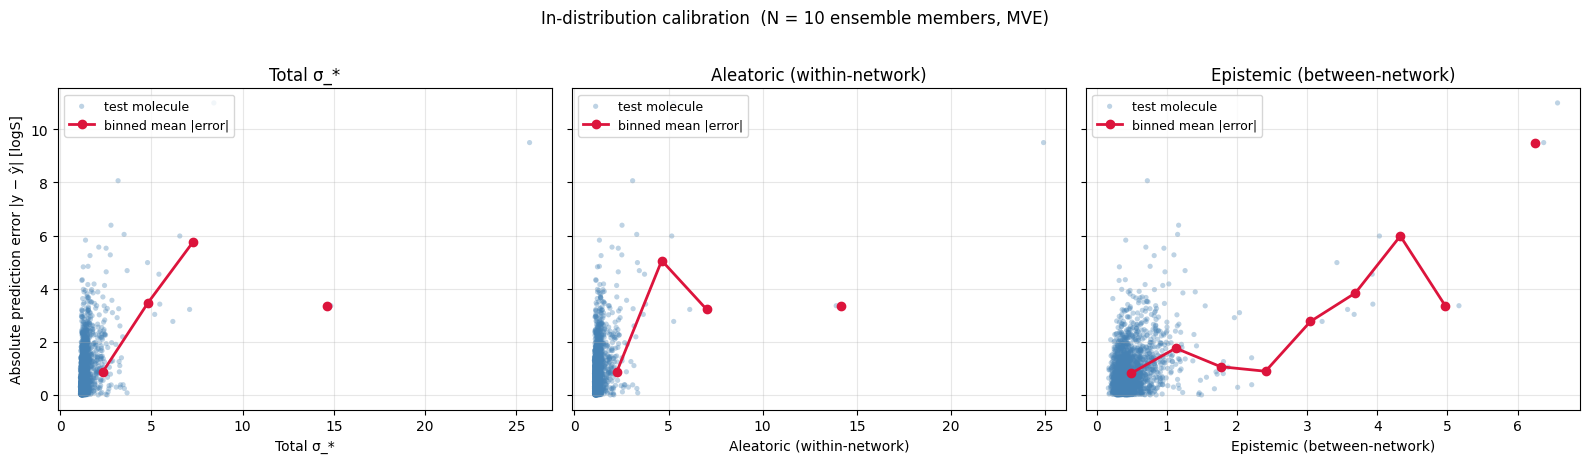

In [9]:
# --- Predict on the in-distribution test set ---

test_smiles = data_frame['smiles'].iloc[test_indices].tolist()
test_targets = data_frame['solubility'].iloc[test_indices].to_numpy()

test_result = predict_with_uncertainty(test_smiles, ensemble)
test_mean = test_result['mean']
test_std = test_result['std']
test_aleatoric = test_result['aleatoric_std']
test_epistemic = test_result['epistemic_std']
test_abs_error = np.abs(test_mean - test_targets)

# Aggregate statistics:
print(f'Ensemble test RMSE      : {np.sqrt(np.mean((test_mean - test_targets)**2)):.3f} logS')
print(f'Ensemble test MAE       : {np.mean(test_abs_error):.3f} logS')
print(f'Ensemble test R²        : {1 - np.sum((test_mean - test_targets)**2) / np.sum((test_targets - test_targets.mean())**2):.3f}  (literature ceiling ≈ 0.86–0.89)')
print(f'Pearson(|error|, total) : {np.corrcoef(test_abs_error, test_std)[0, 1]:.3f}')
print(f'Pearson(|error|, aleat.): {np.corrcoef(test_abs_error, test_aleatoric)[0, 1]:.3f}')
print(f'Pearson(|error|, epist.): {np.corrcoef(test_abs_error, test_epistemic)[0, 1]:.3f}')


# --- Scatter |error| vs total uncertainty, with a binned running mean ---

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, vals, name in zip(
    axes,
    [test_std, test_aleatoric, test_epistemic],
    ['Total σ_*', 'Aleatoric (within-network)', 'Epistemic (between-network)'],
):
    ax.scatter(vals, test_abs_error, alpha=0.35, s=14, c='steelblue',
               edgecolor='none', label='test molecule')

    n_bins = 10
    bin_edges = np.linspace(vals.min(), vals.max(), n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_means = np.array([
        test_abs_error[(vals >= lo) & (vals < hi)].mean()
        if ((vals >= lo) & (vals < hi)).any() else np.nan
        for lo, hi in zip(bin_edges[:-1], bin_edges[1:])
    ])
    ax.plot(bin_centers, bin_means, color='crimson', marker='o', linewidth=2,
            label='binned mean |error|')
    ax.set_xlabel(f'{name}')
    ax.grid(alpha=0.3)
    ax.set_title(name)
    ax.legend(loc='upper left', fontsize=9)

axes[0].set_ylabel('Absolute prediction error |y − ŷ| [logS]')
fig.suptitle(f'In-distribution calibration  (N = {ENSEMBLE_SIZE} ensemble members, MVE)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### Per-Member Performance

Before trusting the *spread* of the ensemble, it is worth checking the members themselves: how accurate is each one on the test set, and does averaging actually help? The table and bar plot below compare every member's RMSE and MAE against the ensemble mean (dashed / dotted reference lines). Members with different activations land at slightly different accuracies; a healthy ensemble's mean prediction should be at least as good as its average member.

Per-member test-set performance:
  member  activation    RMSE     MAE
       1    softplus   1.292   0.885
       2    softplus   1.219   0.881
       3        tanh   1.379   1.010
       4        relu   1.749   1.141
       5        tanh   1.165   0.844
       6         elu   1.318   0.907
       7         elu   1.565   1.141
       8        relu   1.427   0.993
       9         elu   1.218   0.803
      10    softplus   1.619   1.161
    ens.      (mean)   1.271   0.893

mean single-member RMSE = 1.395 logS;  ensemble RMSE = 1.271 logS  (ensembling helps)


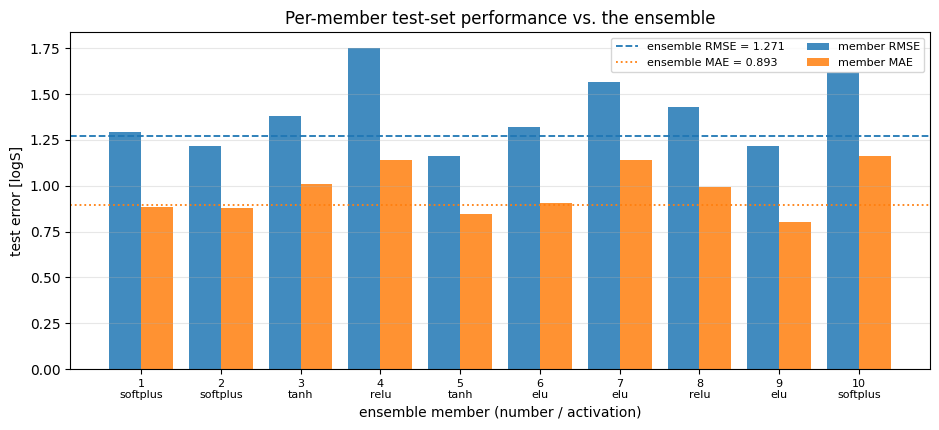

In [10]:
# --- Per-member test-set performance ---
# How good is each *individual* ensemble member on its own, and does averaging them
# actually help? We read the per-member predictions stored in `test_result['mus']`
# (shape (N_test, M)) and compare each member's RMSE/MAE against the ensemble mean.
# A healthy deep ensemble should end up at least as accurate as its average member.
member_rmse, member_mae = [], []
for j in range(test_result['mus'].shape[1]):
    pred = test_result['mus'][:, j]
    mask = ~np.isnan(pred)
    err = pred[mask] - test_targets[mask]
    member_rmse.append(float(np.sqrt(np.mean(err ** 2))))
    member_mae.append(float(np.mean(np.abs(err))))

ens_pred = test_mean
ens_rmse = float(np.sqrt(np.mean((ens_pred - test_targets) ** 2)))
ens_mae = float(np.mean(np.abs(ens_pred - test_targets)))
acts = [h['activation'] for h in member_hparams]

print('Per-member test-set performance:')
print(f'  {"member":>6s}  {"activation":>10s}  {"RMSE":>6s}  {"MAE":>6s}')
for j in range(len(member_rmse)):
    print(f'  {j+1:>6d}  {acts[j]:>10s}  {member_rmse[j]:6.3f}  {member_mae[j]:6.3f}')
print(f'  {"ens.":>6s}  {"(mean)":>10s}  {ens_rmse:6.3f}  {ens_mae:6.3f}')
print(f'\nmean single-member RMSE = {np.mean(member_rmse):.3f} logS;  '
      f'ensemble RMSE = {ens_rmse:.3f} logS  '
      f'({"ensembling helps" if ens_rmse < np.mean(member_rmse) else "no ensemble gain"})')

# --- bar plot: per-member RMSE/MAE with the ensemble as reference lines ---
M = len(member_rmse)
x = np.arange(M)
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(x - 0.2, member_rmse, width=0.4, color='tab:blue', alpha=0.85, label='member RMSE')
ax.bar(x + 0.2, member_mae, width=0.4, color='tab:orange', alpha=0.85, label='member MAE')
ax.axhline(ens_rmse, color='tab:blue', ls='--', lw=1.3, label=f'ensemble RMSE = {ens_rmse:.3f}')
ax.axhline(ens_mae, color='tab:orange', ls=':', lw=1.3, label=f'ensemble MAE = {ens_mae:.3f}')
ax.set_xticks(x)
ax.set_xticklabels([f'{j+1}\n{acts[j]}' for j in range(M)], fontsize=8)
ax.set_xlabel('ensemble member (number / activation)')
ax.set_ylabel('test error [logS]')
ax.set_title('Per-member test-set performance vs. the ensemble')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**🔍 Model quality check.** Before reading the uncertainty estimates, it is worth confirming the ensemble itself is sound &mdash; just as Tutorials 2 and 3 evaluate their model before explaining it. Here the ensemble reaches RMSE $\approx 1.27$ logS and R² $\approx 0.71$ on the held-out test set, within the expected range for AqSolDB (whose experimental-noise ceiling sits around R² $\approx 0.86$&ndash;$0.89$). Its mean prediction (RMSE $\approx 1.27$) is more accurate than the average single member (RMSE $\approx 1.40$), so ensembling is paying off, and the per-member spread above &mdash; the best and worst members differ by more than $0.5$ logS RMSE, tracking the activation each drew &mdash; is exactly the functional diversity the epistemic signal relies on. If a re-run ever shows the ensemble no better than its mean member, or the calibration below looks degenerate, simply retrain: the β-NLL loss is somewhat seed-sensitive.

**🔍 Calibration Scatters.** The three panels decompose the ensemble's uncertainty signal into its components. On each panel the horizontal axis is one of the three uncertainty estimates &mdash; the *total* $\sigma_*$ (left), the *aleatoric* contribution from the per-member variance heads (middle), and the *epistemic* contribution from the disagreement between the per-member means (right) &mdash; and the vertical axis is the absolute prediction error of the ensemble mean on the in-distribution test set. The crimson line shows the average absolute error within uncertainty bins. A well-behaved MVE ensemble should produce a positive trend on the *total* and *epistemic* panels (uncertainty rising with error), and a less monotone but still informative signal on the *aleatoric* panel, since the aleatoric component captures *intrinsic* label noise rather than model misspecification &mdash; its correlation with the absolute error reflects whichever molecules the model has implicitly identified as harder to predict.

The reported Pearson correlations quantify each panel's trend in a single number. Values noticeably above zero indicate that the corresponding uncertainty component carries information about the ensemble's own reliability. Comparing the three correlations is itself informative: an MVE ensemble in which only the *epistemic* correlation is meaningful is essentially a vanilla deep ensemble, with the variance heads contributing nothing; one in which only the *aleatoric* correlation is meaningful but the epistemic one is flat is a sign that the members converged to nearly identical solutions and the deep-ensemble half of the recipe failed.

In this run all three correlations are clearly positive (total $\approx 0.43$, aleatoric $\approx 0.40$, epistemic $\approx 0.46$): both halves of the recipe contribute, and the epistemic spread carries the most error-information &mdash; confirming the deep-ensemble component is doing real work.

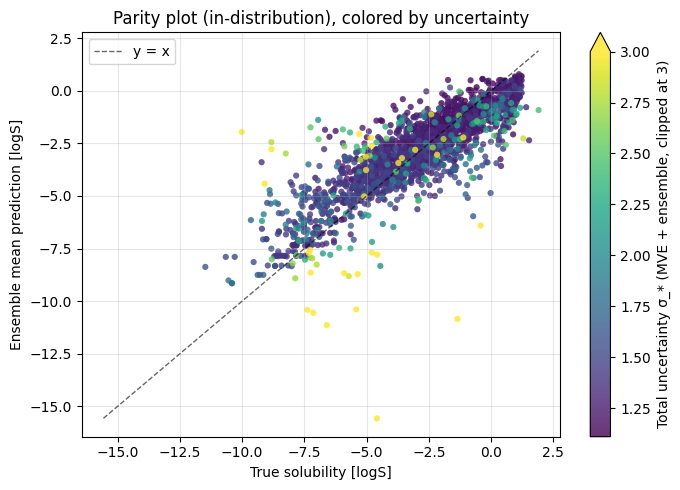

In [ ]:
# --- Parity plot colored by total uncertainty (color clipped for contrast) ---
# The raw total sigma_* has a few extreme outliers (sigma ~ 25) that would otherwise dominate
# the color scale and wash out the bulk of the data. We therefore *clip* the color
# value at COLOR_CAP: any molecule with sigma_* above the cap is drawn in the top color, so
# the 1-3 logS band where the vast majority of molecules sit spans the full colormap.
COLOR_CAP = 3.0

fig, ax = plt.subplots(figsize=(7, 5))
c = np.clip(test_std, None, COLOR_CAP)
order = np.argsort(c)  # draw the high-uncertainty points on top
sc = ax.scatter(test_targets[order], test_mean[order],
                c=c[order], cmap='viridis', vmin=float(test_std.min()), vmax=COLOR_CAP,
                s=20, alpha=0.8, edgecolor='none')

# y = x reference line
lo, hi = min(test_targets.min(), test_mean.min()), max(test_targets.max(), test_mean.max())
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.6, label='y = x')

cb = fig.colorbar(sc, ax=ax, extend='max')  # the arrow marks points clipped to the cap
cb.set_label(f'Total uncertainty σ_* (MVE + ensemble, clipped at {COLOR_CAP:g})')

ax.set_xlabel('True solubility [logS]')
ax.set_ylabel('Ensemble mean prediction [logS]')
ax.set_title('Parity plot (in-distribution), colored by uncertainty')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**🔍 Parity Plot.** The horizontal axis shows the true measured solubility, the vertical axis the ensemble's mean prediction, and each point's color encodes the ensemble's uncertainty estimate. The dashed black line is the ideal $y = x$ relationship. A well-calibrated ensemble should show two patterns at once: the cloud of points lies tightly along the diagonal, indicating low prediction error on average; and the *yellow / high-uncertainty* points are precisely the ones that stray furthest from the diagonal, while the *dark / low-uncertainty* points cluster tightly around it. If the high-uncertainty points were instead scattered at random &mdash; some on the diagonal, some far from it &mdash; the uncertainty estimate would be uninformative. In this run that is broadly what we see: the brightest (highest-uncertainty) points concentrate among those that fall furthest from the diagonal.

### Uncertainty&ndash;Residual Parity Plot

A particularly informative calibration diagnostic &mdash; used as the *main* visualization tool by [Kellner & Ceriotti (2024)](https://arxiv.org/abs/2402.16621) &mdash; is the **uncertainty&ndash;residual parity plot**. It scatters the absolute prediction error $|\Delta y| = |\hat{y} - y|$ against the predicted uncertainty $\sigma$ on **log&ndash;log axes**.

First, what does *calibrated* mean here? An uncertainty is calibrated if its claimed error bars are honest: the true value should land inside the predicted $\pm\sigma$ interval about $68\%$ of the time, inside $\pm 2\sigma$ about $95\%$ of the time, and so on. Comparing claimed-versus-actual coverage gives a *calibration curve*, and the *miscalibration area* defined below is the gap between that curve and the ideal.

The interpretation rests on a simple observation: if the model is perfectly calibrated, then at a given predicted $\sigma$ the residual is distributed as $\Delta y \sim \mathcal{N}(0, \sigma^2)$. On logarithmic axes this Gaussian deforms into an asymmetric bell whose *mode* sits exactly on the dashed $\Delta y = \sigma$ line, and a fixed fraction of points should fall within each shaded quantile band:

- **[15&ndash;85%]** (red) &mdash; the central *70%* of well-calibrated points,
- **[5&ndash;95%]** (orange) &mdash; the central *90%*,
- **[.5&ndash;99.5%]** (green) &mdash; the central *99%*.

Points sitting systematically *above* the dashed line have errors *larger* than their claimed uncertainty, which means the reported $\sigma$ is too small &mdash; the model is *over-confident*. Points sitting systematically *below* the line have errors smaller than their claimed uncertainty and indicate *under-confidence*. We annotate two scalar diagnostics from the paper &mdash; the *miscalibration area (MA)* and the *relative log-likelihood (RLL)* &mdash; defined in the box below.

<details style="border: 1.5px solid #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 The two calibration metrics: MA and RLL</summary>

**Miscalibration area (MA).** The area between the observed calibration curve and the ideal diagonal. $0$ means perfectly calibrated; *lower is better*.

**Relative log-likelihood (RLL)** (eq. 7 of the paper). A Gaussian log-likelihood of the residuals under the predicted $\sigma$, normalized so that *higher is better*: $100\%$ matches a per-sample oracle that magically sets each $\sigma$ equal to that point's actual error, $0\%$ is no better than predicting a single constant error (the RMSE), and negative values are worse than that constant baseline.

</details>

We put the ensemble's *total* uncertainty $\sigma_*$ (epistemic $\oplus$ aleatoric) on the axis of *both* panels &mdash; this is the quantity you would report as a calibrated error bar &mdash; and the right panel applies a post-hoc recalibration fit on a *dedicated calibration set*:

- **Designate a calibration set.** Post-hoc recalibration must be fit on data the ensemble did *not* train on, and on a subset *disjoint* from the one we finally score (otherwise the calibration is circular). The training molecules were seen during fitting, so we split the held-out *test* set into a *calibration* half (which fits the recalibration) and an *evaluation* half (everything plotted and scored below). In a production pipeline this would be a separate validation split reserved up front.
- **Fit an affine variance recalibration** $\hat\sigma^2 = a\,\sigma_*^2 + b$ on the calibration set by minimising the Gaussian NLL ([affine recalibration; arXiv:2405.02461](https://arxiv.org/abs/2405.02461)). The multiplicative factor $a$ rescales the spread; the additive term $b$ adjusts the constant noise floor (a Gaussian-process "nugget"). This affine form generalizes the two standard recalibrations: $b = 0$ recovers pure multiplicative $\sigma$-scaling (the regression analogue of temperature scaling), and $a = 1$ recovers pure additive noise injection.

**The total $\sigma_*$ is already nearly calibrated, and its left-hand wall is a feature rather than an artefact.** Because the mean&ndash;variance head has learned AqSolDB's $\approx 1.1$ logS label-noise floor, the raw total $\sigma_*$ is close to calibrated out of the box (its RLL is already $> 0$), and the affine recalibration mainly *polishes* it &mdash; lowering the miscalibration area and slightly raising the RLL (here the fit gives $a \approx 0.64$, $b = 0$, taking the MA from $\approx 0.09$ to $\approx 0.03$ and the RLL from $\approx 7\%$ to $\approx 10\%$). The wall on the left of the plot persists in both panels, and that is correct: the floor encodes the irreducible experimental label noise, so no honest, calibrated uncertainty on this dataset can fall below it. (Recalibration shifts the wall to $\sqrt{a\,\sigma_{*,\min}^2 + b}$ but never removes it.) Removing the wall would require dropping the aleatoric term altogether and keeping only the *epistemic* axis; that version looks more like the plots in the paper, but it is badly *over-confident* as an error bar, because it omits the data-noise floor. The practical takeaway is that the affine-recalibrated total $\hat\sigma$ is the quantity to trust as a *calibrated error bar*, whereas the raw epistemic component is the right tool only when the goal is to *rank* extrapolative predictions, as in the OOD analysis below.

calibration set n=1102,  evaluation set n=1102  (disjoint, both unseen during training)
fitted affine recalibration of TOTAL σ_*:  a = 0.644,  b = 0.000
  -> recalibrated noise floor = 0.890 logS  (raw total σ_* floored at 1.110)


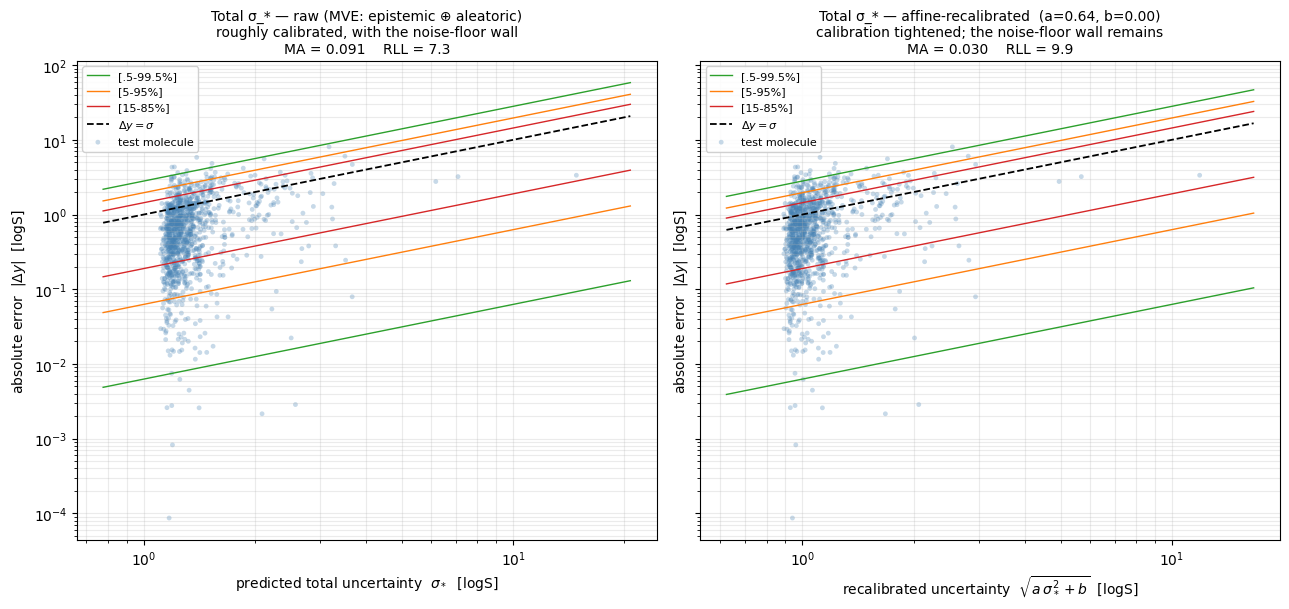


evaluation set (n=1102):
  raw total σ_*       : MA=0.091  RLL=7.3%
  affine-recalibrated : MA=0.030  RLL=9.9%


In [12]:
# --- Uncertainty-residual parity plot (Kellner & Ceriotti, arXiv:2402.16621) ---
#
# Both panels use the ensemble's TOTAL uncertainty sigma_* (epistemic + aleatoric); the
# right panel applies an AFFINE variance recalibration fit on a dedicated, held-out
# calibration set:
#
#   (left)  RAW total sigma_* -- the MVE ensemble's native uncertainty. Already roughly
#           calibrated (the aleatoric head learned the ~1 logS label-noise floor),
#           but that floor shows up as the left-hand "wall".
#
#   (right) AFFINE-RECALIBRATED  sigma_hat = sqrt(a*sigma_*^2 + b)  (cf. arXiv:2405.02461). A
#           post-hoc polish: 'a' rescales the spread, 'b' is an additive noise floor.
#           Fit by NLL on the calibration set, it tightens the calibration further.
#           The wall remains (the noise floor is real); affine recalibration moves
#           it to sqrt(b'), where b' = a*sigma_*,min^2 + b.

from scipy.stats import norm
from scipy.optimize import minimize


def _gaussian_nll(abs_err: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """Per-sample Gaussian negative log-likelihood, NLL = 0.5 (delta_y^2/sigma^2 + ln 2*pi*sigma^2)."""
    sigma = np.clip(sigma, 1e-9, None)
    return 0.5 * (abs_err ** 2 / sigma ** 2 + np.log(2 * np.pi * sigma ** 2))


def uq_calibration_metrics(abs_err: np.ndarray, sigma: np.ndarray) -> tuple[float, float]:
    """
    Compute the miscalibration area (MA) and relative log-likelihood (RLL).

    MA integrates |observed - expected| coverage of the standardized residuals over all
    central confidence levels (0 = perfectly calibrated). RLL (eq. 7 of the paper) places
    the model's mean NLL on a scale where 100% is a per-sample oracle (sigma = |delta_y|) and 0% is
    a constant-error baseline (sigma = RMSE); negative means worse than that baseline.
    """
    abs_err = np.asarray(abs_err, dtype=float)
    sigma = np.clip(np.asarray(sigma, dtype=float), 1e-9, None)

    rmse = np.sqrt(np.mean(abs_err ** 2))
    nll_model = _gaussian_nll(abs_err, sigma).sum()
    nll_oracle = _gaussian_nll(abs_err, np.clip(abs_err, 1e-9, None)).sum()  # sigma = |delta_y|
    nll_const = _gaussian_nll(abs_err, np.full_like(abs_err, rmse)).sum()    # sigma = RMSE
    rll = (nll_model - nll_const) / (nll_oracle - nll_const) * 100.0

    # miscalibration area from two-sided coverage of the standardized residuals
    z = abs_err / sigma
    levels = np.linspace(0.01, 0.99, 99)
    observed = np.array([(z <= norm.ppf((1 + p) / 2)).mean() for p in levels])
    ma = np.trapz(np.abs(observed - levels), levels)
    return ma, rll


def plot_uncertainty_residual(sigma: np.ndarray,
                              abs_err: np.ndarray,
                              ax: plt.Axes = None,
                              title: str = '',
                              xlabel: str = r'predicted total uncertainty  $\sigma_*$  [logS]',
                              ) -> tuple[float, float]:
    """
    Draw an uncertainty-residual parity plot: |delta_y| vs sigma on log-log axes, with the
    dashed delta_y = sigma reference and the [15-85%] / [5-95%] / [.5-99.5%] Gaussian quantile
    bands. Returns the (MA, RLL) calibration metrics, which are also shown in the title.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 6.5))

    sigma = np.clip(np.asarray(sigma, dtype=float), 1e-9, None)
    abs_err = np.clip(np.asarray(abs_err, dtype=float), 1e-9, None)

    # Quantile bands: for a calibrated Gaussian, |delta_y|/sigma has the half-normal quantiles
    # c(p) = Phi^-1((1+p)/2); each band is bounded by a lower and an upper line c*sigma.
    bands = [(0.005, 0.995, '#2ca02c', '[.5-99.5%]'),
             (0.05, 0.95, '#ff7f0e', '[5-95%]'),
             (0.15, 0.85, '#d62728', '[15-85%]')]
    x_line = np.array([sigma.min() * 0.7, sigma.max() * 1.4])
    for lo, hi, color, label in bands:
        ax.plot(x_line, norm.ppf((1 + lo) / 2) * x_line, color=color, lw=1.0)
        ax.plot(x_line, norm.ppf((1 + hi) / 2) * x_line, color=color, lw=1.0, label=label)
    ax.plot(x_line, x_line, 'k--', lw=1.3, label=r'$\Delta y = \sigma$')

    ax.scatter(sigma, abs_err, s=12, alpha=0.30, c='steelblue', edgecolor='none',
               label='test molecule')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'absolute error  $|\Delta y|$  [logS]')
    ax.grid(alpha=0.25, which='both')

    ma, rll = uq_calibration_metrics(abs_err, sigma)
    head = (title + '\n') if title else ''
    ax.set_title(f'{head}MA = {ma:.3f}    RLL = {rll:.1f}', fontsize=10)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    return ma, rll


# === Designate a dedicated calibration set =====================================
# Post-hoc recalibration MUST be fit on data the ensemble did not train on, and on a
# subset DISJOINT from the one we finally score. The training molecules were seen
# during fitting (their residuals are over-optimiztic), so we carve both the
# calibration and the evaluation set out of the held-out *test* set.
CALIB_FRAC = 0.5
rng = np.random.default_rng(0)
_perm = rng.permutation(len(test_std))
_n_cal = int(CALIB_FRAC * len(_perm))
calib_idx, eval_idx = _perm[:_n_cal], _perm[_n_cal:]

# === Fit the affine variance recalibration  sigma_hat^2 = a*sigma_*^2 + b ====================
# (Affine recalibration, cf. arXiv:2405.02461.) We fit a, b >= 0 by minimising the
# Gaussian NLL on the CALIBRATION set, using a softplus parametrization to keep both
# non-negative. We recalibrate the TOTAL uncertainty sigma_* here.
_sig_c = np.clip(test_std[calib_idx], 1e-9, None)
_err_c = test_abs_error[calib_idx]
_sp = lambda x: np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)   # stable softplus


def _nll_affine(theta):
    var = _sp(theta[0]) * _sig_c ** 2 + _sp(theta[1])
    return 0.5 * np.mean(np.log(2 * np.pi * var) + _err_c ** 2 / var)


_opt = minimize(_nll_affine, x0=[1.0, 0.0], method='Nelder-Mead',
                options=dict(xatol=1e-4, fatol=1e-6, maxiter=2000))
a_cal, b_cal = float(_sp(_opt.x[0])), float(_sp(_opt.x[1]))


def recalibrate(sigma: np.ndarray) -> np.ndarray:
    """Affine variance recalibration:  sigma -> sqrt(a*sigma^2 + b)."""
    return np.sqrt(a_cal * np.clip(sigma, 0.0, None) ** 2 + b_cal)


print(f'calibration set n={len(calib_idx)},  evaluation set n={len(eval_idx)}  '
      f'(disjoint, both unseen during training)')
print(f'fitted affine recalibration of TOTAL σ_*:  a = {a_cal:.3f},  b = {b_cal:.3f}')
print(f'  -> recalibrated noise floor = {recalibrate(np.array([test_std.min()]))[0]:.3f} logS  '
      f'(raw total σ_* floored at {test_std.min():.3f})')

# === Parity plots on the EVALUATION set ========================================
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), sharey=True)
ma_raw, rll_raw = plot_uncertainty_residual(
    test_std[eval_idx], test_abs_error[eval_idx], ax=axes[0],
    title='Total σ_* — raw (MVE: epistemic ⊕ aleatoric)\nroughly calibrated, with the noise-floor wall',
)
ma_cal, rll_cal = plot_uncertainty_residual(
    recalibrate(test_std[eval_idx]), test_abs_error[eval_idx], ax=axes[1],
    title=f'Total σ_* — affine-recalibrated  (a={a_cal:.2f}, b={b_cal:.2f})\n'
          'calibration tightened; the noise-floor wall remains',
    xlabel=r'recalibrated uncertainty  $\sqrt{a\,\sigma_*^2 + b}$  [logS]',
)
plt.tight_layout()
plt.show()

print(f'\nevaluation set (n={len(eval_idx)}):')
print(f'  raw total σ_*       : MA={ma_raw:.3f}  RLL={rll_raw:.1f}%')
print(f'  affine-recalibrated : MA={ma_cal:.3f}  RLL={rll_cal:.1f}%')

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 4.2** $\cdot$ The dominant source of *functional* diversity in this ensemble is the per-member activation choice. Try pinning every member to a single activation &mdash; for example set `ACTIVATION_CHOICES = ['relu']` &mdash; so that the only remaining diversity is random initialisation and the small optimization-hyperparameter jitter, then retrain. How does the Pearson correlation between uncertainty and error in the calibration scatter change, and how does the separation between the OOD tiers in the violin plot change? What does this tell you about how much of the ensemble's signal comes from activation diversity versus initialisation and optimization noise?

</div>

### Out-of-Distribution Detection

A calibrated in-distribution uncertainty score is necessary but not sufficient for a UQ method to be useful in practice. What we ultimately care about is whether the ensemble's uncertainty *rises* when the model is presented with molecules outside the distribution it was trained on &mdash; ideally well before the model is asked to make predictions that downstream users would otherwise blindly trust.

To probe this, we construct three out-of-distribution sets, each roughly 40&ndash;60 molecules in size, ordered by how far they sit from the AqSolDB training distribution:

| Tier | Description | Source |
|------|-------------|--------|
| **0 (In-dist.)** | Held-out 20% of AqSolDB | The same test set used above |
| **1 (Near-OOD)** | Heaviest molecules in AqSolDB | `load_dataset_aqsoldb_heaviest` &mdash; the 50 highest-molecular-weight AqSolDB entries |
| **2 (Mid-OOD)** | A single genuinely unseen element | `load_dataset_astatine_substituted` &mdash; recognizable halogenated AqSolDB molecules with every F/Cl/Br/I replaced by astatine (At, Z=85), an element absent from AqSolDB and just beyond its heaviest atom (Bi, Z=83) |
| **3 (Far-OOD)** | Large polycyclic aromatic hydrocarbons (PAHs) | `load_dataset_pahs` &mdash; ~50 PAHs spanning 10–42 heavy atoms, from naphthalene up to decacene |

The expectation is that ensemble uncertainty should rise monotonically across these tiers. Note that for tiers 2 and 3 we do *not* have ground-truth solubility values &mdash; which is exactly the realistic deployment scenario UQ is designed for: knowing whether to trust a prediction *before* you can validate it experimentally.

In [13]:
# --- Tier 1: Near-OOD: the 50 heaviest molecules in AqSolDB ---
# Loaded from `xai_chem_review/datasets/aqsoldb_heaviest.csv` via `load_dataset_aqsoldb_heaviest`.
# These molecules are *inside* the AqSolDB distribution by definition (they are AqSolDB rows,
# and so carry a ground-truth solubility), but they sit in its extreme size tail: the training
# set has seen only a handful of comparably large molecules, so the ensemble's behavior here
# is a mild stress test.

tier1_df = load_dataset_aqsoldb_heaviest()
tier1_smiles = tier1_df['smiles'].tolist()
print(f'Tier 1 set: {len(tier1_smiles)} molecules, MW range '
      f'{tier1_df["mw"].min():.0f} - {tier1_df["mw"].max():.0f} Da')

Tier 1 set: 50 molecules, MW range 1169 - 5299 Da


**📝 Note.** Tier 1 molecules are still drawn from AqSolDB itself, so the ensemble *could* in principle have seen some of them during training. We retain them in the analysis as a deliberately mild OOD probe: even within an "in-distribution" dataset, the tails of the size distribution receive sparser training signal than the bulk, and the uncertainty estimate should reflect that. Because the 50 heaviest molecules are drawn from the *whole* dataset, most of them fall in the training split rather than the held-out test set, so the ensemble has seen comparable molecules and its epistemic spread on this tier is, if anything, biased *low* &mdash; any rightward shift we observe is therefore a conservative lower bound. If the uncertainty does not rise even here, that would be an early sign that the UQ signal is too blunt to be useful.

In [14]:
# --- Tier 2: Mid-OOD: a single genuinely unseen element (astatine) ---
# Loaded from `xai_chem_review/datasets/astatine_substituted.csv` via
# `load_dataset_astatine_substituted`. We take recognizable halogenated molecules that really
# occur in AqSolDB and replace every halogen (F, Cl, Br, I) with astatine (At, Z = 85). Astatine
# is a group-17 halogen, so the swap preserves valence and leaves a chemically well-formed
# molecule -- but no astatine compound appears anywhere in AqSolDB, and Z = 85 sits just beyond
# the heaviest training element (Bi, Z = 83). Each molecule is therefore an otherwise-familiar
# structure pushed out of distribution along a single, purely elemental axis: the
# scaled-atomic-number feature jumps to 0.85 (outside the trained range) while every other
# feature stays in-distribution.

tier2_df = load_dataset_astatine_substituted()
tier2_smiles = tier2_df['smiles'].tolist()
print(f'Tier 2 set: {len(tier2_smiles)} astatine-substituted molecules '
      f'(every F/Cl/Br/I -> At, Z = 85; absent from AqSolDB)')

Tier 2 set: 54 molecules (elements Po, At, Ra, Ac, Th, Pa, U, Np, Pu; Z = 84-94, all absent from AqSolDB)


**🔍 Why this set is OOD.** Each atom is encoded partly by its *scaled atomic number* ($Z/100$), so different elements occupy different positions along that one feature axis. The heaviest element anywhere in AqSolDB is bismuth ($Z = 83$); astatine ($Z = 85$) is absent from the training data *and* sits beyond that range, so its feature value ($0.85$) is one the network never saw. Because we substitute astatine into otherwise-real molecules, every *other* feature &mdash; connectivity, ring membership, valence, the remaining atom types &mdash; stays squarely in-distribution. The set therefore isolates a single, clean axis of novelty: the model must *extrapolate* on the element-identity channel alone. Since the ensemble members were initialised differently and use different activation functions, they extrapolate this lone out-of-range value in different directions, which surfaces as elevated *epistemic* (between-member) uncertainty &mdash; though, as we will see, only modestly, precisely because just one channel is perturbed.

In [15]:
# --- Tier 3: Far-OOD: large polycyclic aromatic hydrocarbons (PAHs) (~50 SMILES) ---
# Loaded from `xai_chem_review/datasets/pahs.csv` via the loader function
# `load_dataset_pahs`. These molecules consist purely of fused aromatic carbon rings
# (with a few methylated variants for diversity), ranging from naphthalene (10 atoms)
# up to decacene (42 atoms) and including larger peri-fused systems like coronene.
# They represent a chemistry essentially absent from the AqSolDB training distribution:
# pure C/H composition (so atom-feature one-hots collapse to a single channel),
# hexagonal fused-aromatic topology, very rigid, very large, and famously poorly soluble.

pahs_df = load_dataset_pahs()
tier3_smiles = pahs_df['smiles'].tolist()
print(f'Tier 3 set: {len(tier3_smiles)} PAH molecules')
print(f'  Heavy-atom range: {pahs_df["n_heavy_atoms"].min()} - {pahs_df["n_heavy_atoms"].max()}')
print(f'  MW range:         {pahs_df["mol_weight"].min():.0f} - {pahs_df["mol_weight"].max():.0f} Da')
pahs_df.head()

Tier 3 set: 58 PAH molecules
  Heavy-atom range: 10 - 62
  MW range:         128 - 779 Da


,name,smiles,n_heavy_atoms,mol_weight
0,linear_acene_2_rings,c1ccc2ccccc2c1,10,128.17
1,1-methylnaphthalene,Cc1cccc2ccccc12,11,142.20
2,2-methylnaphthalene,Cc1ccc2ccccc2c1,11,142.20
3,biphenyl,c1ccc(-c2ccccc2)cc1,12,154.21
4,"1,5-dimethylnaphthalene",Cc1cccc2c(C)cccc12,12,156.23


**🔍 Why this set is OOD.** PAHs differ from AqSolDB along nearly every axis simultaneously. (1) *Composition:* they contain only carbon and (implicit) hydrogen, so the atom-feature one-hot encoding collapses to a single channel and the model never sees the heteroatom-pattern signal it relies on for ordinary drug-like molecules. (2) *Topology:* fused hexagonal ring systems are vastly larger and more rigid than the small ring fragments typical of AqSolDB; the very large entries here (8–10 fused rings) have heavy-atom counts well into the tail of AqSolDB. (3) *Solubility:* large PAHs are famously among the least water-soluble organic molecules known, with experimental logS values often below −10 &mdash; well outside the predictive range of any model trained on a drug-like distribution. The ensemble's pooled graph embedding has effectively no training precedent for inputs that combine all three of these properties at once.

### A Look at the Three OOD Sets

Before measuring how the ensemble reacts to these sets, it is worth seeing what they actually contain. The grids below draw a few representative molecules from each tier. For Tier 2 we show the original AqSolDB molecule next to its astatine analogue, so the single-element substitution is visible: the structure is otherwise identical, with only the halogen positions relabelled as astatine (`At`).

Tier 1 -- heaviest AqSolDB molecules:


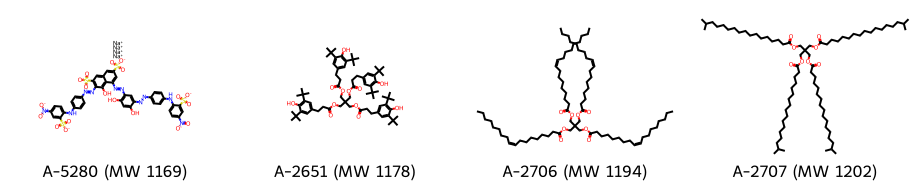

Tier 2 -- parent molecule  ->  astatine analogue:


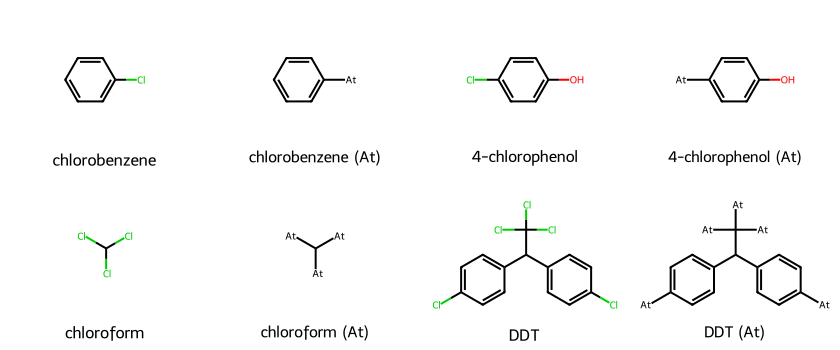

Tier 3 -- polycyclic aromatic hydrocarbons:


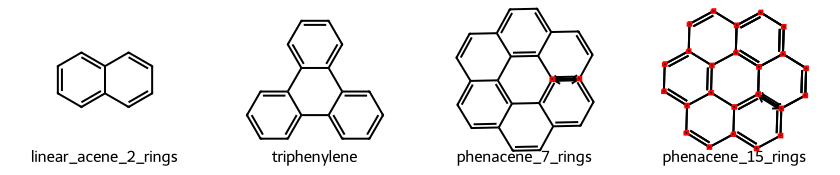

In [ ]:
# --- A few example structures from each OOD tier ---
from rdkit.Chem import Draw
from IPython.display import display

def _mols(smiles_list):
    return [Chem.MolFromSmiles(s) for s in smiles_list]

# Tier 1: four of the heaviest molecules (drawn small -- these are genuinely large).
print('Tier 1 -- heaviest AqSolDB molecules:')
t1_ex = tier1_df.nsmallest(4, 'mw')   # the smaller end of the heavy tail, for legibility
display(Draw.MolsToGridImage(_mols(t1_ex['smiles']), molsPerRow=4, subImgSize=(230, 190),
                             legends=[f'{r.ID} (MW {r.mw:.0f})' for r in t1_ex.itertuples()]))

# Tier 2: parent (real, halogenated) next to its astatine analogue.
print('Tier 2 -- parent molecule  ->  astatine analogue:')
_names = ['chlorobenzene', '4-chlorophenol', 'chloroform', 'DDT']
t2_ex = tier2_df.set_index('name').loc[_names].reset_index()
pairs, legends = [], []
for r in t2_ex.itertuples():
    pairs += [Chem.MolFromSmiles(r.parent_smiles), Chem.MolFromSmiles(r.smiles)]
    legends += [r.name, f'{r.name} (At)']
display(Draw.MolsToGridImage(pairs, molsPerRow=4, subImgSize=(210, 175), legends=legends))

# Tier 3: four PAHs spanning the size range.
print('Tier 3 -- polycyclic aromatic hydrocarbons:')
t3_ex = pahs_df.iloc[[0, len(pahs_df) // 3, 2 * len(pahs_df) // 3, len(pahs_df) - 1]]
display(Draw.MolsToGridImage(_mols(t3_ex['smiles']), molsPerRow=4, subImgSize=(210, 175),
                             legends=[r.name for r in t3_ex.itertuples()]))

Predicting on all three OOD tiers...

Per-tier statistics (median):
  tier                               total    aleat.    epist.     n
  Tier 0 (in-dist.)                  1.265     1.194     0.417  2203
  Tier 1 (heavy)                     3.924     3.209     2.297    50
  Tier 2 (At-subst.)                 1.341     1.262     0.480    41
  Tier 3 (PAHs)                      1.440     1.317     0.623    58


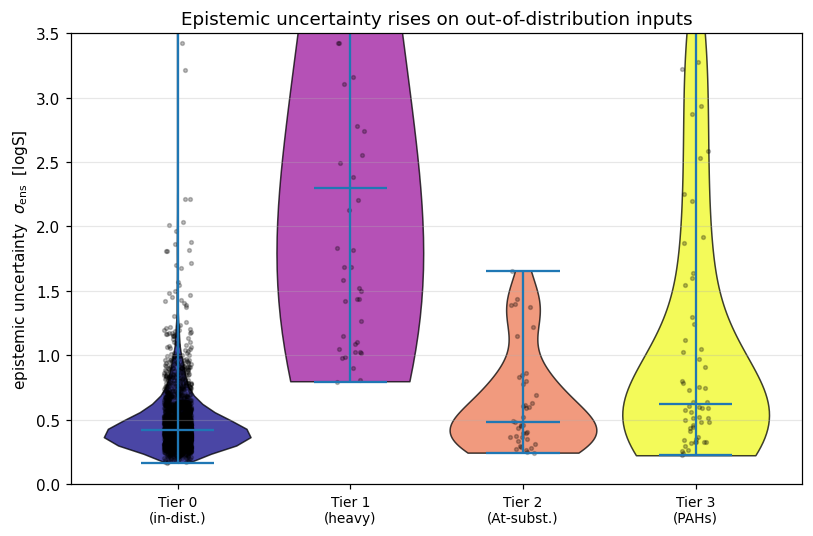

In [ ]:
# --- Compute ensemble uncertainties for every tier ---

print('Predicting on all three OOD tiers...')
tier0_res = predict_with_uncertainty(test_smiles, ensemble)        # in-distribution baseline
tier1_res = predict_with_uncertainty(tier1_smiles, ensemble)
tier2_res = predict_with_uncertainty(tier2_smiles, ensemble)       # Tier 2: astatine-substituted
tier3_res = predict_with_uncertainty(tier3_smiles, ensemble)       # Tier 3: PAHs

# Drop NaNs that arise from SMILES that the encoder could not handle.
def _clean(arr):
    return arr[~np.isnan(arr)]

tier_total = [_clean(r['std']) for r in
              (tier0_res, tier1_res, tier2_res, tier3_res)]
tier_aleat = [_clean(r['aleatoric_std']) for r in
              (tier0_res, tier1_res, tier2_res, tier3_res)]
tier_epist = [_clean(r['epistemic_std']) for r in
              (tier0_res, tier1_res, tier2_res, tier3_res)]
tier_labels = ['Tier 0\n(in-dist.)', 'Tier 1\n(heavy)',
               'Tier 2\n(At-subst.)', 'Tier 3\n(PAHs)']

# Print a numerical summary of ALL THREE components. Note how the *total* and
# *aleatoric* medians barely move across tiers -- they are pinned near the ~1 logS
# data-noise floor -- whereas the *epistemic* median climbs with shift severity.
# That is exactly why we use the epistemic component as the OOD signal below.
print('\nPer-tier statistics (median):')
print(f'  {"tier":30s}  {"total":>8s}  {"aleat.":>8s}  {"epist.":>8s}  {"n":>4s}')
for label, t, a, e in zip(tier_labels, tier_total, tier_aleat, tier_epist):
    label_inline = label.replace("\n", " ")
    print(f'  {label_inline:30s}  {np.median(t):8.3f}  {np.median(a):8.3f}  '
          f'{np.median(e):8.3f}  {len(t):4d}')


# --- Single-panel violin of the EPISTEMIC uncertainty across tiers ---
# Epistemic (between-member disagreement) is the OOD signal: it carries no data-noise
# floor and rises specifically on unfamiliar inputs. The total / aleatoric components
# (see the table above) are dominated by the constant ~1 logS noise floor, which masks
# the novelty signal -- so we do NOT use them for OOD here.
fig, ax = plt.subplots(figsize=(7.5, 5.0))
cmap = plt.cm.plasma

parts = ax.violinplot(tier_epist, positions=range(len(tier_epist)),
                      showmedians=True, widths=0.85)
for i, body in enumerate(parts['bodies']):
    body.set_facecolor(cmap(i / (len(tier_epist) - 1)))
    body.set_alpha(0.75)
    body.set_edgecolor('black')
for i, vals in enumerate(tier_epist):
    jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(np.full_like(vals, i) + jitter, vals, s=6, color='black', alpha=0.25)

ax.set_xticks(range(len(tier_epist)))
ax.set_xticklabels(tier_labels, fontsize=9)
ax.set_ylabel(r'epistemic uncertainty  $\sigma_\mathrm{ens}$  [logS]')
ax.set_title('Epistemic uncertainty rises on out-of-distribution inputs', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Fixed y-axis range so the Tier 1 / Tier 3 violins are not clipped at the top.
ax.set_ylim(0.0, 3.5)

plt.tight_layout()
plt.show()

### Uncertainty&ndash;Residual Parity Plot, Coloured by Tier

Following [Kellner & Ceriotti (2024)](https://arxiv.org/abs/2402.16621), we can overlay the datasets on a *single* uncertainty&ndash;residual parity plot, coloring the points by tier, to see whether the more out-of-distribution molecules migrate towards higher predicted uncertainty (to the right) and higher error (upward). Here the horizontal axis is the *epistemic* uncertainty $\sigma_\mathrm{ens}$ &mdash; the OOD signal &mdash; rather than the total $\sigma_*$, whose constant $\approx 1$ logS aleatoric floor would compress the tiers together on the left. The grey lines are the Gaussian quantile guides ([15&ndash;85%], [5&ndash;95%], [.5&ndash;99.5%]) and the dashed line is $\Delta y = \sigma$.

Because the vertical axis is the *absolute error* $|\Delta y|$, only tiers with ground-truth solubility can appear: **Tier 0** (in-distribution test) and **Tier 1** (heaviest AqSolDB molecules). Tiers 2 and 3 have no reference values, so they cannot be placed on this axis (their epistemic distributions appear in the violin plot above). The horizontal axis is clipped to focus on the bulk rather than the extreme tail.

Note that on the *epistemic* axis the points sit *above* the $\Delta y = \sigma$ line: the epistemic spread alone is not a calibrated error bar, because it omits the data-noise floor (for calibrated bars, use the affine-recalibrated total $\hat\sigma$ from §4.3). What matters here is *relative* migration: the Tier 1 cloud should shift to the *right* of the Tier 0 bulk, marking the heavier, sparser-sampled molecules as more uncertain.

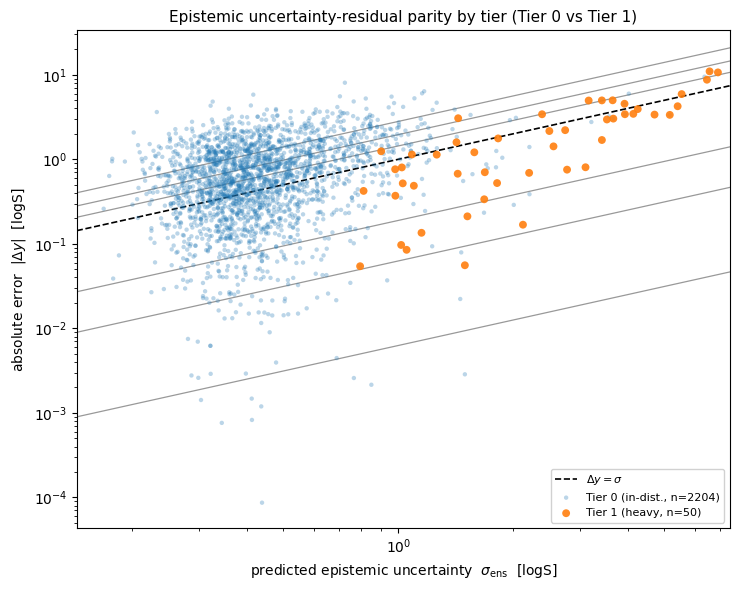

Median epistemic sigma:  Tier 0 = 0.414,  Tier 1 = 2.297
x-axis upper limit: 7.43 logS  (2 of 2254 points beyond it, off-canvas)


In [17]:
# --- Uncertainty-residual parity plot, colored by tier (cf. Kellner & Ceriotti 2024) ---
from scipy.stats import norm

# We use the EPISTEMIC uncertainty sigma_ens on the x-axis -- the OOD signal -- rather than
# the total sigma_*, whose ~1 logS aleatoric floor would compress the tier separation.
# The vertical axis is the absolute error |delta_y|, which requires a ground-truth solubility.
# Only Tier 0 (in-distribution test) and Tier 1 (heaviest AqSolDB molecules) have labels;
# Tiers 2 and 3 have no reference values, so they cannot appear on this plot.
sig0, err0 = test_epistemic, test_abs_error
tier1_targets = tier1_df['solubility'].to_numpy()
m1 = ~np.isnan(tier1_res['mean'])
sig1 = tier1_res['epistemic_std'][m1]
err1 = np.abs(tier1_res['mean'][m1] - tier1_targets[m1])

fig, ax = plt.subplots(figsize=(7.5, 6.0))

# x-range: include all of Tier 1 (so it stays visible) while clipping only the extreme
# upper tail of the in-distribution epistemic distribution.
all_sigma = np.concatenate([sig0, sig1])
x_lo = all_sigma.min() * 0.85
# Clip at the larger of Tier-0's 99th pct and Tier-1's 95th pct (x1.1): keeps the full
# Tier-1 bulk visible while dropping a couple of extreme heavy-molecule sigma outliers.
x_hi = max(np.percentile(sig0, 99), np.percentile(sig1, 95)) * 1.1

# y-range taken from the actual absolute errors (with a margin), so the guide lines no
# longer stretch the axis.
all_err = np.clip(np.concatenate([err0, err1]), 1e-9, None)
y_lo, y_hi = all_err.min() * 0.5, all_err.max() * 2.0

# Grey Gaussian quantile guide-lines (|dy| = c*sigma), drawn only across the visible x-range.
x_line = np.array([x_lo, x_hi])
for p in [0.005, 0.05, 0.15, 0.85, 0.95, 0.995]:
    ax.plot(x_line, norm.ppf((1 + p) / 2) * x_line, color='0.6', lw=0.9, zorder=1)
ax.plot(x_line, x_line, 'k--', lw=1.2, zorder=2, label=r'$\Delta y = \sigma$')

ax.scatter(sig0, np.clip(err0, 1e-9, None), s=10, alpha=0.30, c='tab:blue',
           edgecolor='none', zorder=3, label=f'Tier 0 (in-dist., n={len(sig0)})')
ax.scatter(sig1, np.clip(err1, 1e-9, None), s=32, alpha=0.90, c='tab:orange',
           edgecolor='none', zorder=5, label=f'Tier 1 (heavy, n={len(sig1)})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel(r'predicted epistemic uncertainty  $\sigma_\mathrm{ens}$  [logS]')
ax.set_ylabel(r'absolute error  $|\Delta y|$  [logS]')
ax.set_title('Epistemic uncertainty-residual parity by tier (Tier 0 vs Tier 1)', fontsize=11)
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

print('Median epistemic sigma:  Tier 0 = %.3f,  Tier 1 = %.3f' % (np.median(sig0), np.median(sig1)))
n_clip = int((all_sigma > x_hi).sum())
print(f'x-axis upper limit: {x_hi:.2f} logS  ({n_clip} of {len(all_sigma)} points beyond it, off-canvas)')

**🔍 Epistemic Uncertainty Across OOD Tiers.** We use the *epistemic* component $\sigma_\mathrm{ens}$ (the spread between ensemble members) as the out-of-distribution signal. This is the original deep-ensemble disagreement measure: on familiar inputs the members agree (low epistemic), on unfamiliar ones they extrapolate in different directions (high epistemic). Critically, it carries *no data-noise floor*, so unlike the total $\sigma_*$ it is free to fall toward zero in-distribution and to rise specifically with novelty.

The numerical table above shows why we read the *epistemic* component rather than the total. For the unseen-element and PAH tiers the *total* and *aleatoric* medians stay close to the in-distribution noise floor (total $\approx 1.4$ logS, versus $\approx 1.3$ in-distribution), so on their own they would barely register the shift; only for the extreme heavy-molecule tier does the aleatoric term also spike. The *epistemic* median, by contrast, rises above the in-distribution baseline ($\approx 0.41$) for *every* OOD tier.

Reading the violin plot: each violin is the distribution of $\sigma_\mathrm{ens}$ over one tier, with the individual molecules jittered in black. A useful diagnostic is *which kind* of novelty each tier represents &mdash; high epistemic together with low aleatoric means "the model knows it does not know" (novel chemistry, not merely noisy chemistry). In this run all three OOD tiers sit above the baseline: Tier 1 (heavy molecules) by far the most ($\approx 2.3$), followed by Tier 3 (PAHs, $\approx 0.62$) and then Tier 2 (the astatine-substituted molecules, $\approx 0.48$). Notably the astatine tier &mdash; though genuinely out-of-vocabulary &mdash; is the *subtlest* signal, barely above the in-distribution baseline, because it differs from the training data along only a single feature axis; we return to why in §4.4. For *calibrated error bars* &mdash; as opposed to OOD ranking &mdash; you would instead use the affine-recalibrated total $\hat\sigma$ from §4.3.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 4.3** $\cdot$ For Tier 3 (PAHs), examine the relationship between PAH size (number of heavy atoms) and ensemble uncertainty. Does uncertainty grow monotonically with size, or does it saturate? The `pahs_df` DataFrame already carries an `n_heavy_atoms` column &mdash; plot it on the x-axis against the per-molecule total/epistemic uncertainty to inspect.

</div>

## **4.4** $\cdot$ 🔬 Discussion and Limitations

Deep ensembles with mean-variance estimation give a simple, widely deployed route to uncertainty quantification for molecular property prediction, but the resulting estimates come with several caveats worth keeping in mind.

**The Experimental Noise Floor.** AqSolDB aggregates *experimental* solubility measurements, and those carry an irreducible inter-source disagreement of roughly $0.6$&ndash;$1.0$ logS. That noise is *aleatoric*: no model, however good, can predict a label more precisely than the label was measured. The mean-variance head learns exactly this. Its predicted aleatoric $\sigma$ converges to a near-constant value of $\approx 1.2$ logS (close to the test RMSE of $\approx 1.27$ logS) and makes up the large majority &mdash; roughly $90\%$ &mdash; of the total variance. The visible consequence is a hard floor: the total $\sigma_*$ never drops below $\approx 1.1$ logS, which is the vertical "wall" on the left of the parity plot in §4.3. That floor is a feature rather than an artefact &mdash; it is the model honestly reporting that the data itself is only good to $\approx 1$ logS, and it is exactly what makes the total uncertainty calibrated.

The *epistemic* component behaves in the opposite way. It is the disagreement *between* ensemble members &mdash; model uncertainty, in principle reducible with more data &mdash; and it has no noise floor: it falls toward zero where members agree and rises where they extrapolate. This is why the two components are used for different jobs. The recalibrated *total* $\sigma_*$ is the right *calibrated error bar*, while the *epistemic* spread is the right *OOD / novelty signal*. On a near-noiseless dataset &mdash; DFT-computed labels, say &mdash; the aleatoric floor would be close to zero and the two would nearly coincide; it is specifically AqSolDB's experimental noise that pulls them apart.

**Ensemble Size.** We use $N = 10$ members here. The between-member standard deviation is still a modest-sample statistic, so its absolute values shift somewhat between random seeds and would tighten further with larger ensembles; the *qualitative* behavior &mdash; uncertainty rising across the OOD tiers, positive correlation with error &mdash; is the robust part. Ensemble size trades inference cost against the stability of the uncertainty signal.

**Ensemble Diversity.** A deep ensemble only works if its members make *different* mistakes; if they all converge to the same solution, the spread collapses and the signal vanishes. In this notebook we deliberately drop bagging and architectural variation, and source the members' diversity from three milder knobs instead: random initialisation, small batch-size and learning-rate jitter, and a randomly chosen activation function per member. That choice carries its own lesson, visible in the tiers above. Activation and initialisation diversity inject a roughly *input-independent* baseline disagreement &mdash; they raise the epistemic magnitude *everywhere*, including in-distribution, so the OOD signal is whatever rises *above* that baseline rather than an absolute level. Data-driven (bagging) and architectural diversity, by contrast, tend to concentrate disagreement specifically where the training data is sparse. What matters is less the sheer amount of diversity than whether the resulting disagreement lands where the model is actually extrapolating.

**Detecting Different Kinds of Novelty.** All three OOD tiers raise the epistemic uncertainty above the in-distribution baseline (median $\approx 0.42$ logS), but to very different degrees, and the ranking is instructive. Tier 1 (heavy molecules) is flagged by far the most strongly (median $\approx 2.3$): these molecules differ from the training data along *many* axes at once (size, topology, heavy-atom count), so the pooled graph embedding lands far from anything seen in training and the members disagree sharply. The large PAHs of Tier 3 ($\approx 0.62$) come next, again differing along several axes simultaneously (pure C/H composition, fused-ring topology, size). Tier 2 &mdash; recognizable molecules with every halogen swapped for astatine ($Z = 85$) &mdash; is the *subtlest* of the three ($\approx 0.48$), only modestly above baseline. That is exactly what we should expect: these molecules are in-distribution along every axis *except one* &mdash; the scaled-atomic-number channel of a few atoms &mdash; so a single out-of-range feature value nudges the differently-initialised members to disagree only a little. The lesson is that nominal *distance* from the training set does not predict how loudly the model complains; what matters is whether the novelty lands on features the model is actually sensitive to, and how many of them. It also means out-of-vocabulary elements are best caught by an explicit applicability-domain check (for instance, flagging any molecule containing an element outside the training set) rather than by the uncertainty signal alone, whose response to a lone novel element is real but small.

**Uncertainty as a Triage Signal.** A rising ensemble uncertainty signals that *something* about the input is unusual relative to the training data, but not *what*. The same elevated uncertainty could indicate an unseen element, an unusual functional group, or merely an unusually large molecule, and the right downstream action &mdash; discard the prediction, gather more data, or hand it off to an expert &mdash; may depend on which. Uncertainty is therefore best treated as a triage signal that prompts inspection, not as a self-contained diagnosis.

**Reliability of the Aleatoric Estimate.** The MVE variance head does claim a per-input aleatoric uncertainty, but that claim is only meaningful where the head saw training signal. In-distribution it is grounded in observed regions of input space; out-of-distribution it is itself an extrapolation, and it may collapse to anomalously *low* values (nothing in training drove it upward), giving a false impression of confidence. This is the flip side of the previous points, and another reason the *epistemic* spread &mdash; not the aleatoric output &mdash; is the more trustworthy OOD detector.

## **References**

**Datasets**

- Sorkun, M. C., Khetan, A., & Er, S. (2019). AqSolDB, a curated reference set of aqueous solubility and 2D descriptors for a diverse set of compounds. *Scientific Data*, 6(1), 143. https://doi.org/10.1038/s41597-019-0151-1

**Methods**

- Lakshminarayanan, B., Pritzel, A., & Blundell, C. (2017). Simple and scalable predictive uncertainty estimation using deep ensembles. In *Advances in Neural Information Processing Systems* (NeurIPS), 30. https://arxiv.org/abs/1612.01474

- Gal, Y., & Ghahramani, Z. (2016). Dropout as a Bayesian approximation: Representing model uncertainty in deep learning. In *International Conference on Machine Learning* (ICML), 1050–1059. https://arxiv.org/abs/1506.02142 | [GitHub](https://github.com/yaringal/DropoutUncertaintyExps)

- Liu, J. Z., Lin, Z., Padhy, S., Tran, D., Bedrax-Weiss, T., & Lakshminarayanan, B. (2020). Simple and principled uncertainty estimation with deterministic deep learning via distance awareness. In *Advances in Neural Information Processing Systems* (NeurIPS), 33, 7498–7512. https://arxiv.org/abs/2006.10108 | [GitHub](https://github.com/google/uncertainty-baselines)

- Miyato, T., Kataoka, T., Koyama, M., & Yoshida, Y. (2018). Spectral normalization for generative adversarial networks. In *International Conference on Learning Representations* (ICLR). https://arxiv.org/abs/1802.05957 | [GitHub](https://github.com/pfnet-research/sngan_projection)

- Xu, K., Hu, W., Leskovec, J., & Jegelka, S. (2019). How powerful are graph neural networks?. In *International Conference on Learning Representations* (ICLR). https://arxiv.org/abs/1810.00826 | [GitHub](https://github.com/weihua916/powerful-gnns)

- Seitzer, M., Tavakoli, A., Antic, D., & Martius, G. (2022). On the pitfalls of heteroscedastic uncertainty estimation with probabilistic neural networks. In *International Conference on Learning Representations* (ICLR). https://arxiv.org/abs/2203.09168 | [GitHub](https://github.com/martius-lab/beta-nll)

- Nix, D. A., & Weigend, A. S. (1994). Estimating the mean and variance of the target probability distribution. In *Proceedings of the IEEE International Conference on Neural Networks*, 1, 55–60. https://doi.org/10.1109/ICNN.1994.374138

- Teufel, J., Leinweber, A., & Friederich, P. (2025). Improving counterfactual truthfulness for molecular property prediction through uncertainty quantification. In *Explainable Artificial Intelligence (xAI 2025)*. https://github.com/the16thpythonist/truthful_counterfactuals

- Hirschfeld, L., Swanson, K., Yang, K., Barzilay, R., & Coley, C. W. (2020). Uncertainty quantification using neural networks for molecular property prediction. *Journal of Chemical Information and Modeling*, 60(8), 3770–3780. https://doi.org/10.1021/acs.jcim.0c00502

- Dai, J., Adhikari, S., & Wen, M. (2024). Uncertainty quantification and propagation in atomistic machine learning. *arXiv preprint* arXiv:2405.02461. https://arxiv.org/abs/2405.02461

- Kellner, M., & Ceriotti, M. (2024). Uncertainty quantification by direct propagation of shallow ensembles. *arXiv preprint* arXiv:2402.16621. https://arxiv.org/abs/2402.16621 | [GitHub](https://github.com/bananenpampe/DPOSE)

**Software**

- Landrum, G. et al. (2024). RDKit: Open-source cheminformatics software. https://www.rdkit.org

- Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., ... & Chintala, S. (2019). PyTorch: An imperative style, high-performance deep learning library. *Advances in Neural Information Processing Systems*, 32. https://pytorch.org

- Falcon, W. et al. (2019). PyTorch Lightning. https://lightning.ai/docs/pytorch/stable/

- Fey, M., & Lenssen, J. E. (2019). Fast graph representation learning with PyTorch Geometric. In *ICLR Workshop on Representation Learning on Graphs and Manifolds*. https://pytorch-geometric.readthedocs.io

- Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). Exploring network structure, dynamics, and function using NetworkX. In *Proceedings of the 7th Python in Science Conference*, pp. 11–15. https://networkx.org

- Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://scipy.org